# Load in files from Zenodo
Download the starting files from zenodo. If you have run the code before, you can instead use the intermediate checkpoints to start halfway and reduce runtime. 

In [2]:
import requests
import os
from tqdm import tqdm

def download_file(link, file_name):
    response = requests.get(link, stream=True)
    if os.path.exists(file_name):
        print(f"The file {file_name} already exists, the file won't be downloaded")
        return
    total_size = int(response.headers.get('content-length', 0))

    with open(file_name, "wb") as f, tqdm(desc="Downloading file", total=total_size, unit='B', unit_scale=True, unit_divisor=1024,) as bar:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))  # Update progress bar by the chunk size
folder_to_store_zenodo_files = "./zenodo_files"


In [1]:

os.makedirs(folder_to_store_zenodo_files, exist_ok=True)
# This file contains the inchikeys used for the data split. This ensures reproducing the exact same results, 
# alternatively you can of course do the data split yourself, but results might differ slightly. 
download_file("https://zenodo.org/records/18801895/files/data_split_inchikeys.json?download=1", 
              os.path.join(folder_to_store_zenodo_files, "data_split_inchikeys.json"))
download_file("https://zenodo.org/records/16882111/files/merged_and_cleaned_libraries_1.mgf?download=1", 
              os.path.join(folder_to_store_zenodo_files, "merged_and_cleaned_libraries_1.mgf"))


The file ./zenodo_files/data_split_inchikeys.json already exists, the file won't be downloaded
The file ./zenodo_files/merged_and_cleaned_libraries_1.mgf already exists, the file won't be downloaded


# Load in mass spectra
These mass spectra are already precleaned using matchms and contain both the GNPS spectra and the MSnLIb spectra for details about the exact cleaning you can check out the zenodo page: https://zenodo.org/records/16882111 . This contains a notebook with all the downloading and cleaning steps detailed. 

In [3]:
from matchms.importing.load_spectra import load_spectra
from tqdm import tqdm
import os
all_spectra = list(tqdm(load_spectra(os.path.join(folder_to_store_zenodo_files, "merged_and_cleaned_libraries_1.mgf"))))

1017531it [05:36, 3021.46it/s]


### Split data on inchikeys
We use the predefined split for reproducibility, but you can of course make your own inchikey split. 

In [4]:
import json

with open(os.path.join(folder_to_store_zenodo_files, "data_split_inchikeys.json"), "r") as f:
    data_split = json.load(f)

In [5]:
val_inchikeys = set(data_split["val"])
train_inchikeys = set(data_split["train"])
test_inchikeys = set(data_split["test"])

In [ ]:
print(len(val_inchikeys))
print(len(train_inchikeys))
print(len(test_inchikeys))

In [6]:
val_spectra = []
test_spectra = []
train_spectra = []
for spectrum in tqdm(all_spectra):
    inchikey = spectrum.get("inchikey")[:14]
    if inchikey in train_inchikeys:
        train_spectra.append(spectrum)
    elif inchikey in val_inchikeys:
        val_spectra.append(spectrum)
    elif inchikey in test_inchikeys:
        test_spectra.append(spectrum)
    else:
        raise ValueError(f"The inchikey {inchikey} does not appear in the val, test or train inchikeys")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1017531/1017531 [00:02<00:00, 453956.16it/s]


In [ ]:
# Free up some memory :) 
all_spectra = None

# Split data on ionmode

In [7]:
def split_on_ionmode(spectra):
    pos_spectra = []
    neg_spectra = []
    for spectrum in spectra:
        ionmode = spectrum.get("ionmode")
        if ionmode == "positive":
            pos_spectra.append(spectrum)
        elif ionmode == "negative":
            neg_spectra.append(spectrum)
        else:
            raise ValueError(f"The ionmode {ionmode} is not positive or negative")
    return pos_spectra, neg_spectra

In [8]:
pos_val_spectra, neg_val_spectra = split_on_ionmode(val_spectra)
pos_test_spectra, neg_test_spectra = split_on_ionmode(test_spectra)
pos_train_spectra, neg_train_spectra = split_on_ionmode(train_spectra)

In [271]:
print(len(pos_val_spectra) + len(neg_val_spectra))
print(len(pos_test_spectra) + len(neg_test_spectra))
print(len(pos_train_spectra) + len(neg_train_spectra))

52440
49422
915669


# Convert to AnnotatedSpectrumSet
An annotatedSpectrumSet organizes the spectra per inchikey. This makes doing the analysis and ranking much easier.

In [9]:
from ms2query.benchmarking.AnnotatedSpectrumSet import AnnotatedSpectrumSet

pos_test_spectra = AnnotatedSpectrumSet.create_spectrum_set(pos_test_spectra)
pos_train_spectra = AnnotatedSpectrumSet.create_spectrum_set(pos_train_spectra)
pos_val_spectra = AnnotatedSpectrumSet.create_spectrum_set(pos_val_spectra)

Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib
Create mapping from inchikey to spectrum: 100%|████████████████████████████████████████████████████████████████████████| 36473/36473 [00:00<00:00, 254856.01it/s]


In [10]:
from ms2query.benchmarking.AnnotatedSpectrumSet import AnnotatedSpectrumSet

neg_val_spectra = AnnotatedSpectrumSet.create_spectrum_set(neg_val_spectra)
neg_test_spectra = AnnotatedSpectrumSet.create_spectrum_set(neg_test_spectra)
neg_train_spectra = AnnotatedSpectrumSet.create_spectrum_set(neg_train_spectra)

Create mapping from inchikey to spectrum: 100%|██████████████████████████████████████████████████████████████████████| 283790/283790 [00:00<00:00, 403806.06it/s]


In [28]:
print(pos_val_spectra)
print(pos_test_spectra)
print(pos_train_spectra)
print(neg_val_spectra)
print(neg_test_spectra)
print(neg_train_spectra)

36473 spectra for 3119 inchikeys 
34227 spectra for 3092 inchikeys 
631879 spectra for 55572 inchikeys 
15967 spectra for 1614 inchikeys with embeddings
15195 spectra for 1659 inchikeys 
283790 spectra for 29806 inchikeys 


# Add MS2DeepScore embeddings
The MS2DeepScore model was trained on the training split here and is used to add embeddings to the spectra. 

### Download MS2DeepScore model from zenodo

In [11]:
folder_to_store_zenodo_files = "./zenodo_files"
download_file("https://zenodo.org/records/17826815/files/ms2deepscore_model.pt?download=1", 
              os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))

The file ./zenodo_files/ms2deepscore_model.pt already exists, the file won't be downloaded


In [305]:
from ms2deepscore.models import load_model
ms2deepscore_model = load_model(os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))

In [ ]:
pos_val_spectra.add_embeddings(ms2deepscore_model)

In [ ]:
pos_train_spectra.add_embeddings(ms2deepscore_model)

In [ ]:
neg_val_spectra.add_embeddings(ms2deepscore_model)
neg_train_spectra.add_embeddings(ms2deepscore_model)

# Experiment with pos pos comparisons
First we experiment with comparing pos against pos spectra. Once we settled on the best methods, we move to testing negative mode as well. Also we will later test the cross ionization mode capabilities.

# Compute fingerprints
Daylight fingerprints are computed to allow for calculating Tanimoto scores which serve as a measure of chemical similarity.

In [15]:
from ms2query.benchmarking.Fingerprints import Fingerprints
val_fingerprints = Fingerprints.from_spectrum_set(pos_val_spectra, "daylight", 4096)
train_fingerprints = Fingerprints.from_spectrum_set(pos_train_spectra, "daylight", 4096)
val_and_train_fingerprints = Fingerprints.combine_fingerprints(val_fingerprints, train_fingerprints)

Get most common inchi per inchikey: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3119/3119 [00:00<00:00, 19633.20it/s]
Adding fingerprints to Inchikeys: 3119it [00:11, 260.74it/s]
Get most common inchi per inchikey: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 55572/55572 [00:01<00:00, 28793.71it/s]
Adding fingerprints to Inchikeys: 55572it [03:30, 263.65it/s]


### Compute top k inchikeys
MS2Query internally uses the top k closest tanimoto scores for reranking. So for any library candidate molecule the chemically closest library molecules are selected, for which the MS2DeepScores are also computed. This was one of the major improvements in the original MS2Query, here we precompute these topk tanimoto scores. We select the top 100, to later have the freedom to test different numbers of top inchikeys. Spoiler, you don't need 100 (around 5-10 is enough).

In [102]:
from ms2query.benchmarking.TopKTanimotoScores import TopKTanimotoScores
top_k_tanimoto_scores = TopKTanimotoScores.calculate_from_fingerprints(
        train_fingerprints,
        train_fingerprints, k=100,)

# Reranking on thresholds
We discovered that with the new MS2DeepScore model any methods we developed, like average over top 10 closest tanimoto scores, did not improve the ranking accuracy over just picking the highest ms2deepscore from the library. However, to determine if a prediction is reliable the top 10 closest tanimoto scores was very usefull. Here we predict the top 1 highest MS2DeepScore for each query spectrum. For this highest hit the top 100 closest inchikeys are selected followed by computing all corresponing MS2DeepScores with the query spectrum. 

In [ ]:
from ms2query.benchmarking.reference_methods.predict_top_k_ms2deepscore import select_inchikeys_with_highest_ms2deepscore

inchikeys_with_highest_ms2deepscores = select_inchikeys_with_highest_ms2deepscore(
        pos_val_spectra, pos_train_spectra, nr_of_inchikeys_to_select=1, batch_size=1000,)


In [22]:
from ms2query.benchmarking.reference_methods.MS2DeepScoresForTopInChikeys import calculate_MS2DeepScoresForTopKInChikeys
close_tanimoto_scores = calculate_MS2DeepScoresForTopKInChikeys(pos_train_spectra, pos_val_spectra, top_k_tanimoto_scores, inchikeys_with_highest_ms2deepscores)

Calculating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [17:21<00:00, 35.01it/s]


### Save intermediate files

In [24]:
import os
import pickle
intermediates_folder = "./pos_pos_intermediate"
os.makedirs(intermediates_folder, exist_ok=True)
with open(os.path.join(intermediates_folder, "top_1_highest_ms2deepscore_with_100_top_inchikeys.pickle"), "wb") as handle:
    pickle.dump(close_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [33]:
with open(os.path.join(intermediates_folder, "pos_val_spectra_with_embeddings.pickle"), "wb") as handle:
    pickle.dump(pos_val_spectra, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [34]:
with open(os.path.join(intermediates_folder, "pos_val_and_train_fingerprints.pickle"), "wb") as handle:
    pickle.dump(val_and_train_fingerprints, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [103]:
with open(os.path.join(intermediates_folder, "top_k_tanimoto_scores.pickle"), "wb") as handle:
    pickle.dump(top_k_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Optional start from intermediate files

In [68]:
import pickle
import os
intermediates_folder = "./pos_pos_intermediate"

with open(os.path.join(intermediates_folder, "top_1_highest_ms2deepscore_with_100_top_inchikeys.pickle"), "rb") as handle:
    close_tanimoto_scores = pickle.load(handle)
with open(os.path.join(intermediates_folder, "pos_val_spectra_with_embeddings.pickle"), "rb") as handle:
    pos_val_spectra = pickle.load(handle)
with open(os.path.join(intermediates_folder, "pos_val_and_train_fingerprints.pickle"), "rb") as handle:
    val_and_train_fingerprints = pickle.load(handle)
with open(os.path.join(intermediates_folder, "top_k_tanimoto_scores.pickle"), "rb") as handle:
    top_k_tanimoto_scores = pickle.load(handle)

# Test different top k tanimoto scores
Here we load in a run where we selected the highest scoring inchikey based on MS2DeepScore, followed by computing the MS2DeepScores for the top 100 closest inchikeys. Since only one inchikey is selected, the ranking is just done on highest MS2DeepScore, however for the threshold used to determine the reliability we use the top k inchikeys. 

### Compute the tanimoto score for the predicted inchikeys

In [6]:
# Selects the predicted inchikeys
predicted_inchikeys = [list(query.keys())[0] for query in close_tanimoto_scores]

In [7]:
for inchikey in predicted_inchikeys:
    if inchikey is None:
        print("inchikey is None")

In [34]:
from tqdm import tqdm
from matchms.similarity.vector_similarity_functions import jaccard_similarity_matrix
import numpy as np
def get_prediction_tanimoto(predicted_inchikeys, val_spectra, val_and_train_fingerprints):
    assert len(predicted_inchikeys) == len(val_spectra)

    tanimoto_for_prediction = []
    for index, predicted_inchikey in enumerate(tqdm(predicted_inchikeys)):
        if predicted_inchikey is not None:
            correct_inchikey = val_spectra.spectra[index].get("inchikey")[:14]
            predicted_fingerprint = val_and_train_fingerprints.get_fingerprints([predicted_inchikey])[0]
            actual_fingerprint = val_and_train_fingerprints.get_fingerprints([correct_inchikey])[0]
            tanimoto_prediction = jaccard_similarity_matrix(np.array([predicted_fingerprint]), np.array([actual_fingerprint]))[0][0]
            tanimoto_for_prediction.append(tanimoto_prediction)
        else:
            tanimoto_for_prediction.append(0.0)
    return tanimoto_for_prediction


In [ ]:
tanimoto_for_prediction = get_prediction_tanimoto(predicted_inchikeys, pos_val_spectra, val_and_train_fingerprints)

Text(0.5, 1.0, 'tanimoto scores by predicting by MS2DeepScore')

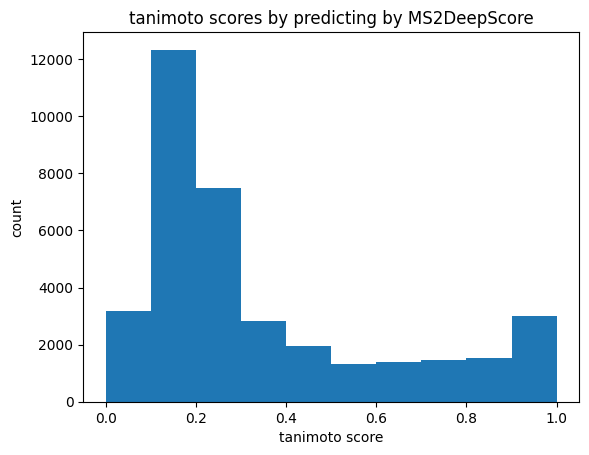

In [9]:
from matplotlib import pyplot as plt
plt.hist(tanimoto_for_prediction)
plt.xlabel("tanimoto score")
plt.ylabel("count")
plt.title("tanimoto scores by predicting by MS2DeepScore")

# How to only select the reliable predictions? 
As you can see many of the highest predicted matches are bad, but some are good. In some cases there simply is no available good library match and sometimes MS2DeepScore just did select a false positive. This picture is similar (or actually worse) for other methods like the modified cosine score, analogue searching is just difficult due to the vast number of options. Therefore, an analogue search is only useful if you can distinguish the good analogues from the bad ones. We need a way to not only predict the best match, but also to convey reliabiltiy to the user, to make library searching usefull. Here we try different approaches for determining reliability. 

The most straightforward way to do this is by using the predicted MS2DeepScore as a guidance for reliability, the higher the predicted MS2DeepScore the more reliable. But there are many more (better) methods for doing this reliability prediction. To measure how well this work, we use such a score for splitting relibable from unreliable matches. We measure this by ranking all the predictions on the score (e.g. ms2deepscore) and retaining different fractions of the predictions. E.g. top 10% until 100%. The general pattern we expect is that the more we fitler out the higher the accuracy of the left over predictions is. 

### Comparison plots and violin plots

We plot this in two ways, one with more details and one to easily compare between different methods. The violin plots show the full distribution of true tanimoto score for the predictions per "bucket" of selected scores. E.g. top 0-10% or top 10-20% of predictions. The second plots just shows the average tanimoto score for the top x percentage. 

The code below separates the prediction in different "buckets" of top 10 and calculates the average tanimoto score for the predictions. It does this on a per inchikey basis. In the validation set most inchikeys have multiple spectra. To make sure we don't judge the quality mostly on an inchikey for which a lot of spectra exist we average the predicted tanimoto per inchikey first. 

In [72]:
import numpy as np

def create_values_violin_plot(predicted_scores, val_spectra, tanimoto_for_predictions, n_buckets):
    """The predictions are ranked based on the predicted scores, and are split in different groups from high to low, 
    for each group the average tanimoto per inchikey is computed."""
    tanimoto_per_bucket = []
    ranked_indexes_per_bucket = bucket_by_value(predicted_scores, n_buckets)
    for indexes_in_bucket in ranked_indexes_per_bucket: 
        average_tanimoto_per_inchikey = get_average_tanimoto_per_inchikey(val_spectra, tanimoto_for_predictions, indexes_in_bucket)
        tanimoto_per_bucket.append(average_tanimoto_per_inchikey)
    return tanimoto_per_bucket

def bucket_by_value(values, n_buckets=10):
    """
    Splits values into n equally sized buckets based on rank. 
    So the highest scores are in the first bucket en the lowest in the last. Each bucket has the same number of values. 
    """
    values = np.array(values)
    # Get indexes that would sort the array descending (top values first)
    sorted_indexes = np.argsort(values)[::-1]
    
    # Split sorted indexes into n equal(ish) buckets
    buckets = np.array_split(sorted_indexes, n_buckets)
    
    return buckets
    
def get_average_tanimoto_per_inchikey(query_spectrum_set, tanimoto_for_predictions, selected_indexes):
    """Calculates the average tanimoto per inchikey for the selected indexes"""
    assert len(tanimoto_for_predictions) == len(query_spectrum_set)
    average_scores_per_inchikey = []
    # Calculate score per unique inchikey
    for inchikey in query_spectrum_set.spectrum_indices_per_inchikey.keys():
        matching_spectrum_indexes = query_spectrum_set.spectrum_indices_per_inchikey[inchikey]
        prediction_scores = []
        for index in matching_spectrum_indexes:
            if index in selected_indexes:
                prediction_scores.append(tanimoto_for_predictions[index])
        if len(prediction_scores) > 0:
            average_prediction = sum(prediction_scores) / len(prediction_scores)
            average_scores_per_inchikey.append(average_prediction)
    return average_scores_per_inchikey

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def plot_violins(data_lists, title="", 
                 figsize=(16, 6), bw_method='scott'):
    """
    Plot side-by-side violin plots for a list of 10 (or any number of) value lists.

    Parameters:
        data_lists   : list of lists/arrays — your 10 groups of values
        title        : plot title
        figsize      : figure size tuple
        bw_method    : KDE bandwidth method ('scott', 'silverman', or float)
    """
    n = len(data_lists)
    labels = [f"{(100/n)*i} - {(100/n)*(i+1)} %" for i in range(n)]

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(
        data_lists,
        positions=range(1, n + 1),
        # showmeans=True,
        showmedians=True,
        showextrema=True,
        bw_method=bw_method
    )

    # Formatting
    ax.set_xticks(range(1, n + 1))
    ax.set_xlabel("Section of ranked predicted scores", fontsize=11, labelpad=10)  
    ax.set_xticklabels(labels, fontsize=11, rotation=30, ha='right')  # <-- rotate labels
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Average Tanimoto score per inchikey", fontsize=11)
    ax.set_xlim(0.3, n + 0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_facecolor('#f9f9f9')
    fig.patch.set_facecolor('white')

    plt.tight_layout()
    plt.show()



# Get the predicted MS2Deepscore
The code below is maybe a bit confusing, since the function is general for getting the average over the top k closest MS2DeepScores. But by setting the number to 1. 

In [10]:
predicted_ms2deepscores = []
for query in tqdm(close_tanimoto_scores):
    predicted_inchikey = list(query.keys())[0]
    ms2deepscores_for_top_inchikeys = list(query.values())[0]
    predicted_ms2deepscores.append(ms2deepscores_for_top_inchikeys.get_max_per_inchikey()[predicted_inchikey])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:05<00:00, 6582.82it/s]


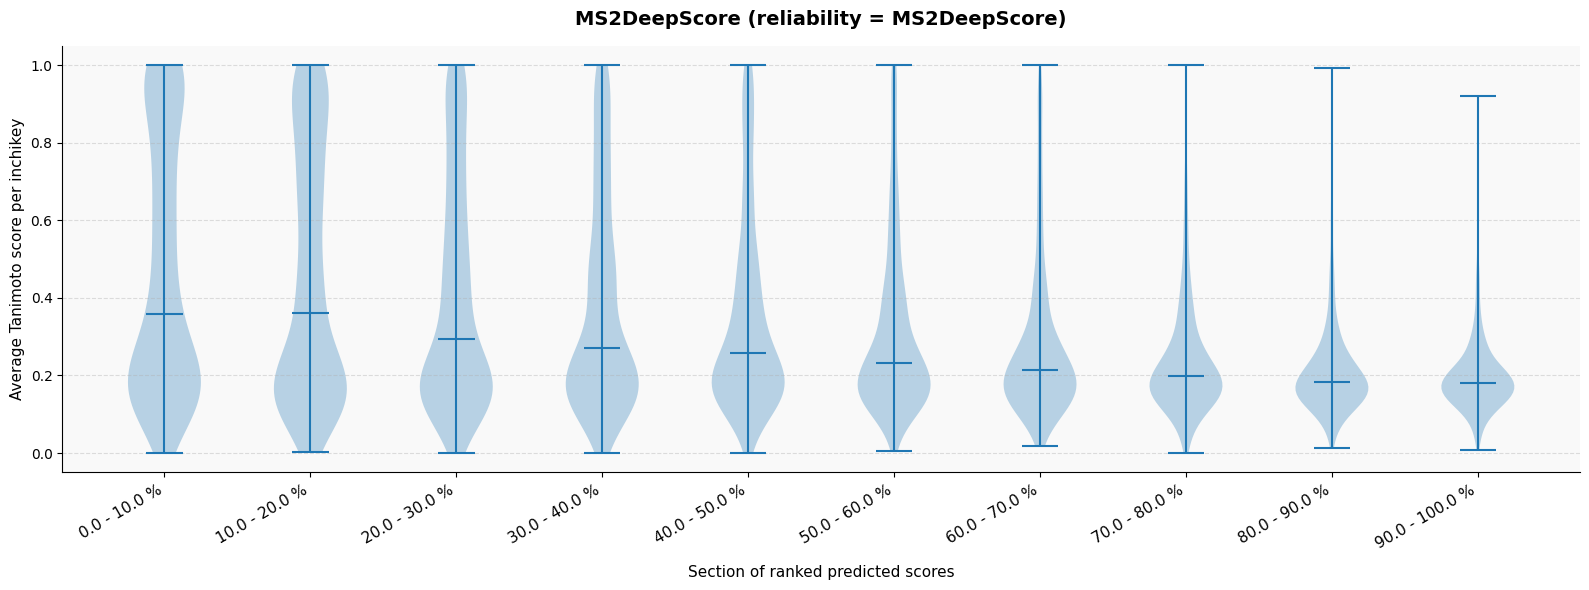

In [243]:
plot_violins(create_values_violin_plot(predicted_ms2deepscores, pos_val_spectra, tanimoto_for_prediction, 10), title="MS2DeepScore (reliability = MS2DeepScore)")

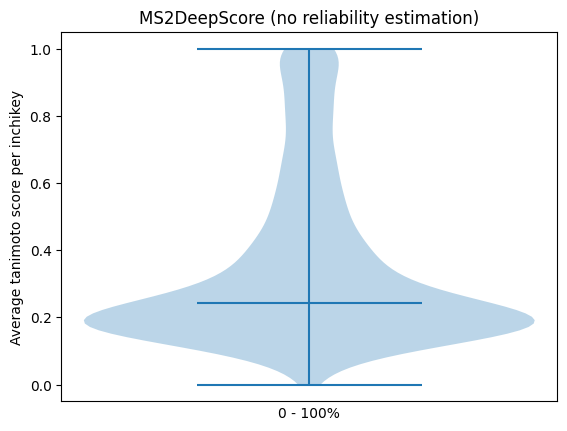

In [133]:
plt.violinplot(create_values_violin_plot(predicted_ms2deepscores, pos_val_spectra, tanimoto_for_prediction, 1), showmedians=True)
plt.title("MS2DeepScore (no reliability estimation)")
plt.ylabel("Average tanimoto score per inchikey")
plt.xticks([])
plt.xlabel("0 - 100%")
plt.show()


### MS2DeepScore improves the prediction accuracy
As you can see selecting the predictions with the highest MS2DeepScores does indeed improve the quality of prediction: For the top 20 percent about 1/3th of the predictions are above 0.6, which is a substantial improvement to not doing any ranking of more reliable predictions. However only 1 out of 3 predictions being useful is still quite low and not very usefull. So can we do better? 

### Using the top k closest tanimoto scores
One of the main strengths of MS2Query was using the predictions for multiple closely related library molecules to get improved predictions. We will use this principle below to do the reranking of candidates. For each predicted library hit, the top 10 (later we try different numbers) most chemically library molecules are selected. For each of these the MS2DeepScores for all spectra were also computed (see code above, they are already stored in close_tanimoto_scores), now we use these to determine how reliabel a prediction is.

In [64]:
def predict_using_average_max_top_k_tanimoto(k, close_tanimoto_scores):
    threshold_score = []
    for spectrum_index, single_query in tqdm(enumerate(close_tanimoto_scores)):
        predicted_inchikey = list(single_query.keys())[0]
        ms2deepscores_for_top_inchikeys = single_query[predicted_inchikey]
        
        inchikey_tanimoto = ms2deepscores_for_top_inchikeys.top_k_inchikeys_and_tanimoto_scores
        top_inchikeys = sorted(inchikey_tanimoto, key=inchikey_tanimoto.get, reverse=True)[:k]
        
        max_per_inchikey = ms2deepscores_for_top_inchikeys.get_max_per_inchikey()
        
        max_ms2deepscore_per_inchikey = [max_per_inchikey[inchikey] for inchikey in top_inchikeys]
        mean_over_max_inchikeys = sum(max_ms2deepscore_per_inchikey)/len(max_ms2deepscore_per_inchikey)
        
        threshold_score.append(mean_over_max_inchikeys)
    return threshold_score

In [61]:
threshold_score_average_max_top_tanimoto = predict_using_average_max_top_k_tanimoto(10, close_tanimoto_scores)

36473it [00:05, 6205.26it/s]


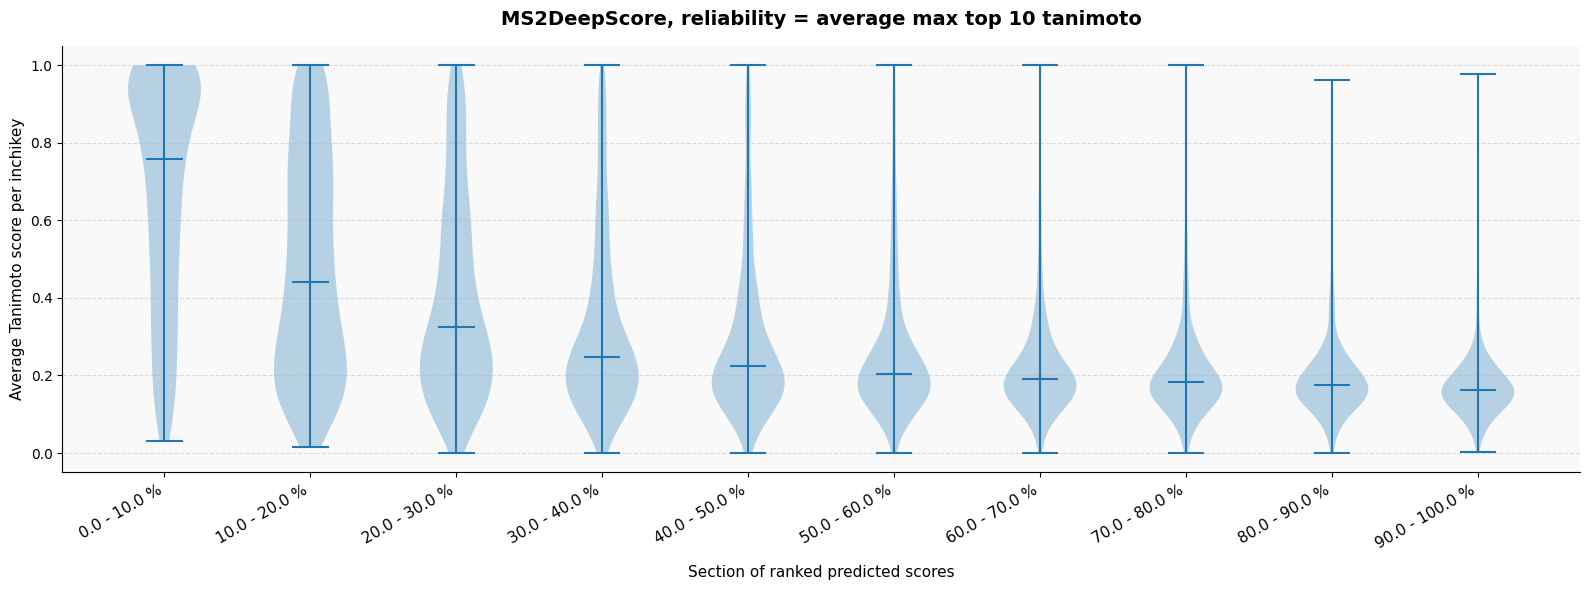

In [137]:
plot_violins(create_values_violin_plot(threshold_score_average_max_top_tanimoto, pos_val_spectra, tanimoto_for_prediction, 10), title="MS2DeepScore, reliability = average max top 10 tanimoto")

# Much better!
By using the average over the max ms2deepscore for the top 10 inchikeys, we can much better predict reliability of the prediction. Now most predictions in the top 10 percent are actually good analogues. 

# Mean ms2deepscore for top 10 tanimoto
There are many different variants to try of this principle. For instance using the mean MS2DeepScore instead of the max. 

In [63]:
def predict_using_average_mean_top_k_tanimoto(k, close_tanimoto_scores):
    threshold_score = []
    for spectrum_index, single_query in tqdm(enumerate(close_tanimoto_scores)):
        predicted_inchikey = list(single_query.keys())[0]
        ms2deepscores_for_top_inchikeys = single_query[predicted_inchikey]
        
        inchikey_tanimoto = ms2deepscores_for_top_inchikeys.top_k_inchikeys_and_tanimoto_scores
        top_inchikeys = sorted(inchikey_tanimoto, key=inchikey_tanimoto.get, reverse=True)[:k]
        
        mean_per_inchikey = ms2deepscores_for_top_inchikeys.get_mean_per_inchikey()
        
        mean_ms2deepscore_per_inchikey = [mean_per_inchikey[inchikey] for inchikey in top_inchikeys]
        mean_over_max_inchikeys = sum(mean_ms2deepscore_per_inchikey)/len(mean_ms2deepscore_per_inchikey)
        
        threshold_score.append(mean_over_max_inchikeys)
    return threshold_score

In [64]:
threshold_score_average_mean_top_tanimoto = predict_using_average_mean_top_k_tanimoto(100, close_tanimoto_scores)

36473it [00:11, 3104.26it/s]


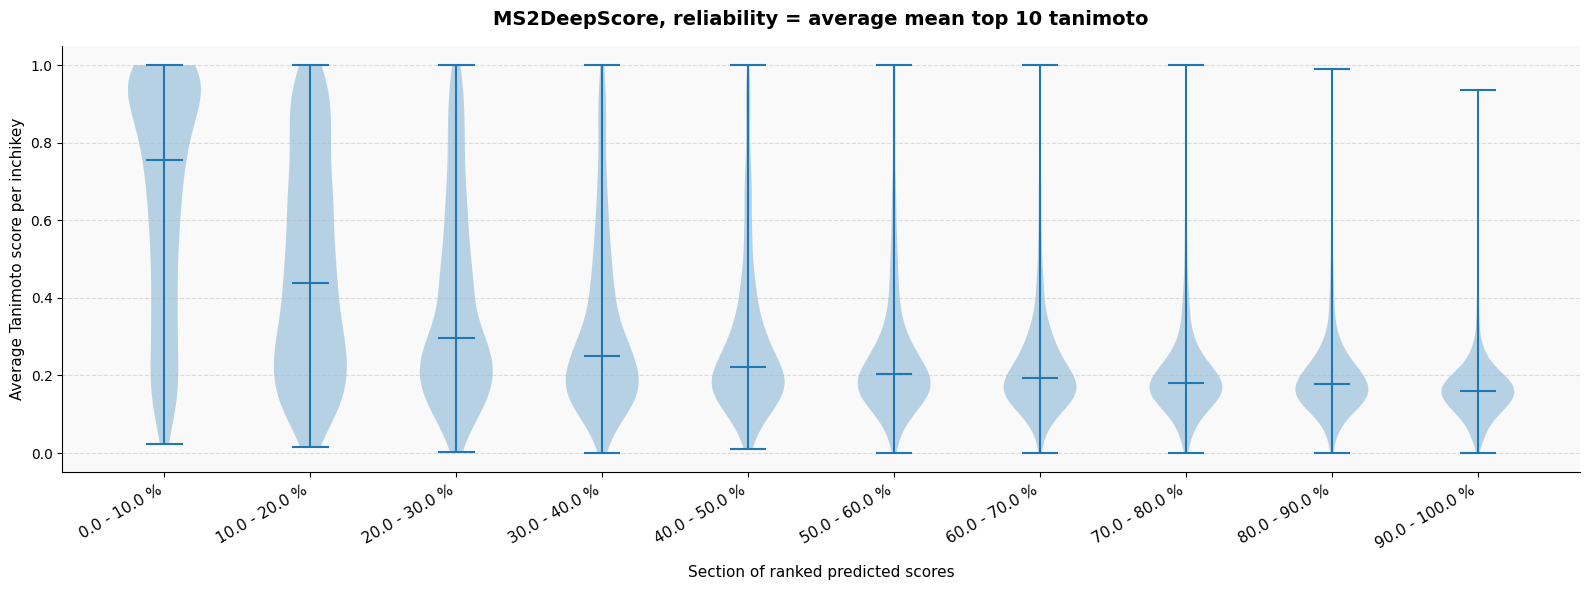

In [138]:
plot_violins(create_values_violin_plot(threshold_score_average_mean_top_tanimoto, pos_val_spectra, tanimoto_for_prediction, 10), title="MS2DeepScore, reliability = average mean top 10 tanimoto")

# MS2Query
So time for the real test! How does this stack up against the original MS2Query. For this purpose we retrained an MS2Query model (including MS2DeepScore and Spec2Vec) using the exact same data split. This was version 1.5.4 of MS2Query. Since the original release many updates were done, to keep it compatible with new versions of dependencies, like for instance MS2DeepScore (moving to pytorch). But the architecture of MS2Query did not change compared to the paper we published. Only the underlying way we train MS2DeepScore was changed slightly with the change to pytorch, but this will only have improved performance compared to the orginal MS2Query paper.
The MS2Query model trained can be downloaded from https://zenodo.org/records/18926063. However, for the benchmarking we only need the actual predictions made by MS2Query, which are downloaded with the code below. 

In [68]:
folder_to_store_zenodo_files = "./zenodo_files"
os.makedirs(folder_to_store_zenodo_files, exist_ok=True)
download_file("https://zenodo.org/records/18926063/files/results_ms2query.csv?download=1", 
              os.path.join(folder_to_store_zenodo_files, "results_ms2query.csv"))

The file ./zenodo_files/results_ms2query.csv already exists, the file won't be downloaded


In [69]:
import pandas as pd

ms2query_results = pd.read_csv(os.path.join(folder_to_store_zenodo_files, "results_ms2query.csv"))

### Convert MS2Query results
We extract the predicted inchikey and the predicted MS2Query score. MS2Query does some additional filtering, requiring a minimum number of peaks for instance. If this is the case the prediction is set to None (which results in a tanimoto of 0.0) and the predicted score to 0, so they are first to be filtered out. Likely these spectra are anyway hard to predict for and will therefore have bad predictions. 

In [70]:
inchikeys = []
predicted_score = []
for i in tqdm(range(len(pos_val_spectra))):
    index = ms2query_results.index[ms2query_results['query_spectrum_nr'] == i+1]
    if len(index) == 1:
        inchikeys.append(ms2query_results["inchikey"][index].tolist()[0])
        predicted_score.append(ms2query_results["ms2query_model_prediction"][index].tolist()[0])
    else:
        inchikeys.append(None)
        predicted_score.append(0.0)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:10<00:00, 3358.89it/s]


In [71]:
tanimoto_for_prediction_ms2query = get_prediction_tanimoto(inchikeys, pos_val_spectra, val_and_train_fingerprints)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:01<00:00, 25663.07it/s]


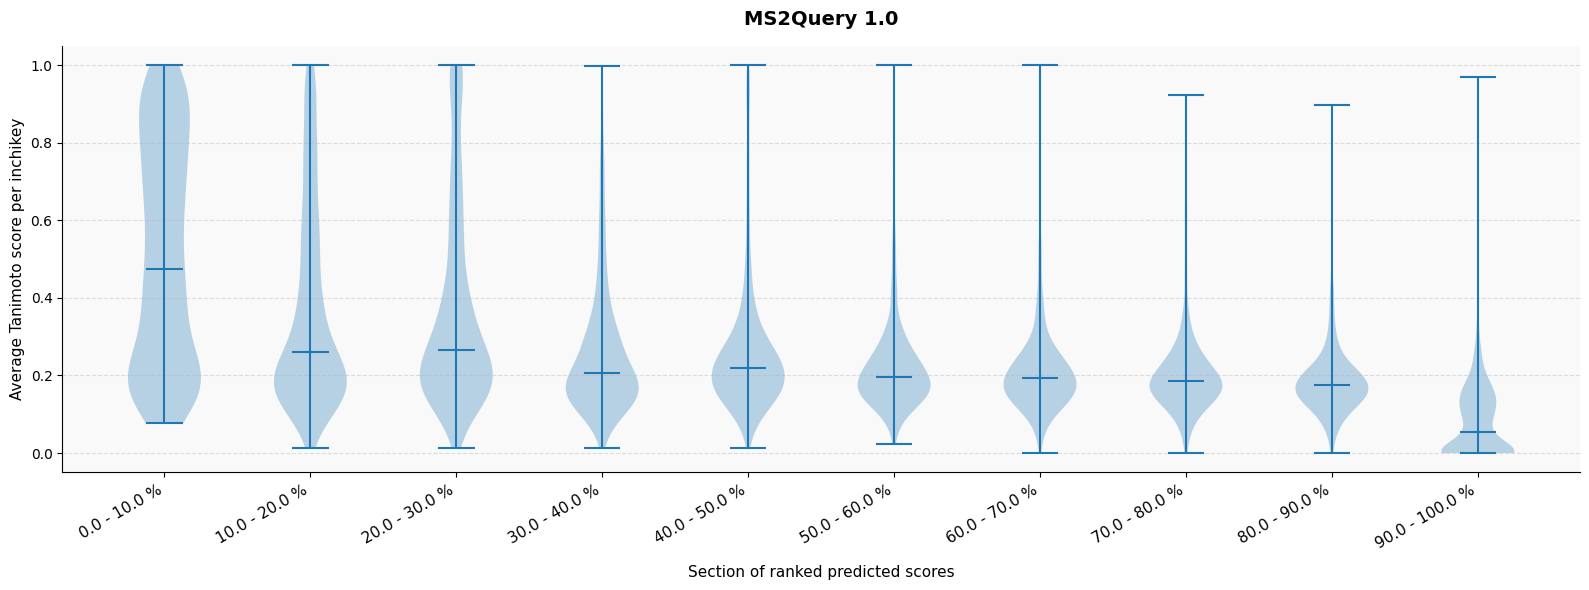

In [139]:
tanimoto_per_bucket = create_values_violin_plot(predicted_score, pos_val_spectra, tanimoto_for_prediction_ms2query, 10)
plot_violins(tanimoto_per_bucket, title="MS2Query 1.0")

### So the new method is better than MS2Query 1.0
MS2Query does a bit better than just using MS2DeepScore, but the new method using MS2DeepScore for the best match, but reliability prediction by the MS2DeepScore for top 10 inchikeys, is quite a bit better than MS2Query

# How far could you improve reliability prediction in theory?
Here we mostly focus on improving reliability prediction, without touching which inchikey is actually predicted. To give an indication of how close to perfect we are, we plot the perfect reliability prediction (just by using the known tanimoto). Actual analogue search accuracy can even be better, if you also change which analogue is predicted, here we just use the inchikey predicted by MS2DeepScore, but using a perfect reliability prediction.

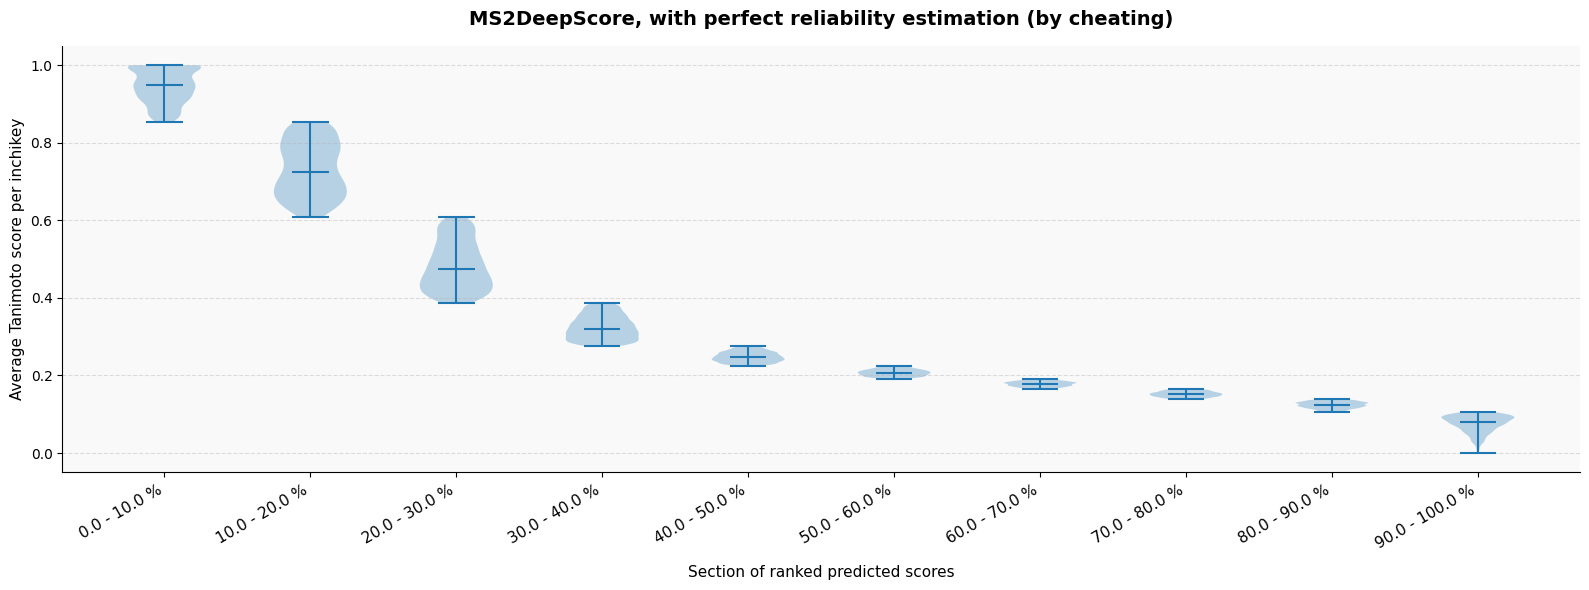

In [140]:
tanimoto_per_bucket = create_values_violin_plot(tanimoto_for_prediction, pos_val_spectra, tanimoto_for_prediction, 10)
plot_violins(tanimoto_per_bucket, title="MS2DeepScore, with perfect reliability estimation (by cheating)")

# Comparison plot
So far we made violin plots, which are nice to explore details in the distribution, however, they make it a bit challenging to compare different methods. Now we switch to a different plot, here we get the mean tanimoto score for the prediction, so we can compare the results side by side. Also we change the plot to show the average over the top percentage, instead of specific bins. So 0- 50 percent instead of only 40-50%. This is similar similar to the benchmarking in the original MS2Query paper and gives an impression of actual average accuracy when using different minimum reliability scores.

In [42]:
def plot_average_per_threshold(predicted_scores, tanimoto_for_predictions, val_spectra, n_of_buckets):
    buckets = bucket_by_value(predicted_scores,n_of_buckets)
    mean_per_fraction = []
    selected_indexes = set()
    for indexes_in_bucket in tqdm(buckets):
        selected_indexes.update(set(indexes_in_bucket.tolist()))
        average_scores_per_inchikey = get_average_tanimoto_per_inchikey(val_spectra, tanimoto_for_predictions, selected_indexes)
        mean = sum(average_scores_per_inchikey)/len(average_scores_per_inchikey)
        mean_per_fraction.append(mean)
    return mean_per_fraction

In [249]:

        
mean_per_fraction_ms2query = plot_average_per_threshold(predicted_score, tanimoto_for_prediction_ms2query, pos_val_spectra, 100)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 343.04it/s]


In [254]:
mean_per_fraction_best_possible_ranker = plot_average_per_threshold(tanimoto_for_prediction, tanimoto_for_prediction, pos_val_spectra, 100)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 351.27it/s]


In [255]:
mean_per_fraction_average_max_top_tanimoto = plot_average_per_threshold(threshold_score_average_max_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 100)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 351.48it/s]


In [256]:
mean_per_ms2deepscore = plot_average_per_threshold(predicted_ms2deepscores, tanimoto_for_prediction, pos_val_spectra, 100)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 345.22it/s]


In [257]:
mean_per_fraction_average_mean_top_tanimoto = plot_average_per_threshold(threshold_score_average_mean_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 100)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 351.32it/s]


In [40]:
from matplotlib import pyplot as plt

def plot_comparison_plot(results):
    n = len(list(results.values())[0])
    labels = [f"0 - {(100/n)*(i+1)} %" for i in range(n)]
    for label, mean_per_fraction in results.items():
        plt.plot(labels, mean_per_fraction, label = label)
    
    plt.xlabel("Fraction predicted")
    plt.ylabel("Average Tanimoto")
    plt.legend()
    plt.ylim((0, 1))
    
    step = n // 10
    positions = range(len(labels))
    
    plt.xticks(
        ticks=positions[step-1::step],    # start at 9, then 19, 29, ...
        labels=labels[step-1::step],
        rotation=45,
        ha='right'
    )
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.show()

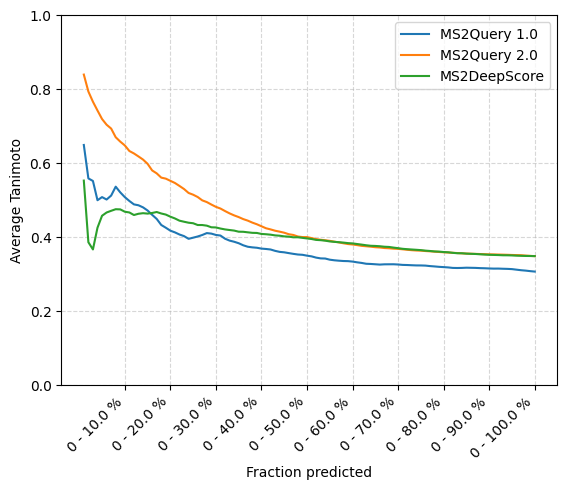

In [259]:
plot_comparison_plot({"MS2Query 1.0": mean_per_fraction_ms2query,
                     "MS2Query 2.0": mean_per_fraction_average_mean_top_tanimoto,
                     "MS2DeepScore": mean_per_ms2deepscore})

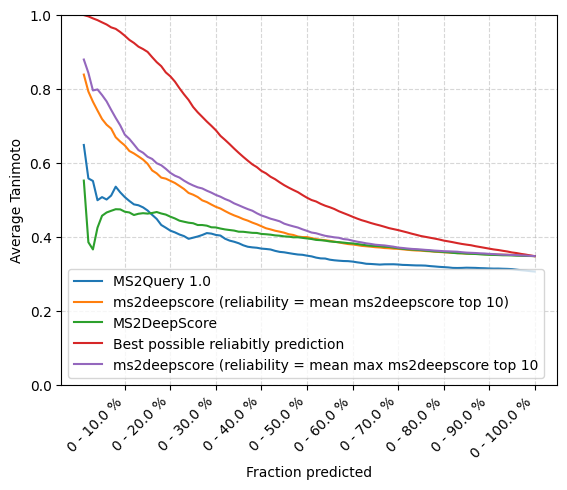

In [266]:
plot_comparison_plot({"MS2Query 1.0": mean_per_fraction_ms2query,
                     "ms2deepscore (reliability = mean ms2deepscore top 10)": mean_per_fraction_average_mean_top_tanimoto,
                     "MS2DeepScore": mean_per_ms2deepscore,
                     "Best possible reliabitly prediction": mean_per_fraction_best_possible_ranker,
                      "ms2deepscore (reliability = mean max ms2deepscore top 10": mean_per_fraction_average_max_top_tanimoto})

# Is top 10 best? 
Below we try different number of top spectra we can select. 

### Try different top inchikeys using the mean MS2DeepScore

In [208]:
results_average_mean_top_k_mean_highest_ms2deepscore = {}
for i in [1,3,5,6,7,8,9,10,11,12,13,14,15, 20, 50]:
    mean_top_k = predict_using_average_mean_top_k_tanimoto(i, close_tanimoto_scores)
    results_average_mean_top_k_mean_highest_ms2deepscore[f"Average mean top {i}"] = plot_average_per_threshold(mean_top_k, tanimoto_for_prediction, pos_val_spectra, 100)


36473it [00:11, 3186.97it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 336.32it/s]
36473it [00:11, 3106.09it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 331.56it/s]
36473it [00:11, 3180.90it/s]
100%|████████████████████████████████████████████████████████

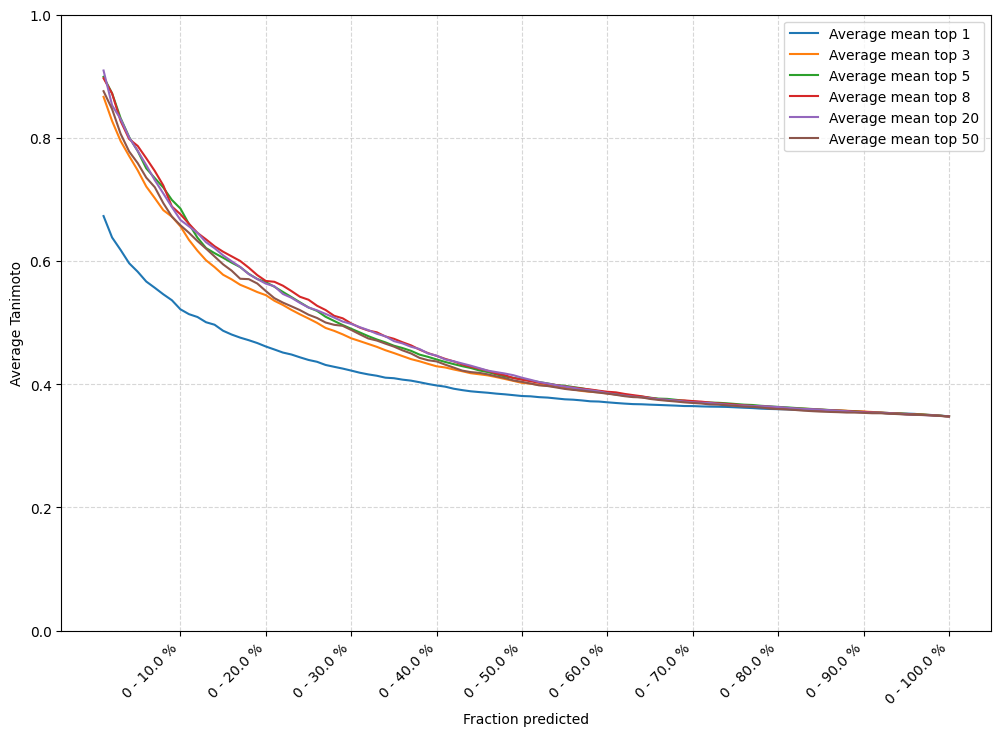

In [284]:
plt.figure(figsize=(12, 8))
# plot_comparison_plot(results_average_mean_top_k_mean_highest_ms2deepscore)
plot_comparison_plot({key: results_average_mean_top_k_mean_highest_ms2deepscore[key] for key in ['Average mean top 1',
                                                                                                 'Average mean top 3',
                                                                                                 'Average mean top 5',
                                                                                                 'Average mean top 8',
                                                                                                 # 'Average mean top 9',
                                                                                                 'Average mean top 20',
                                                                                                 'Average mean top 50',

                                                                                     
]})

# A bit too many lines...
Below the same results, but flipped. The x axis now shows the number of top k hits used and the individual lines are for which fraction of the query spectra a prediction is made. (the x axis/fraction predicted in the previous plot). So somewhere between top 5 and top 10 seems fine, where 8 seems best overall. 

Text(0.5, 0, 'Nr of close library Inchikeys')

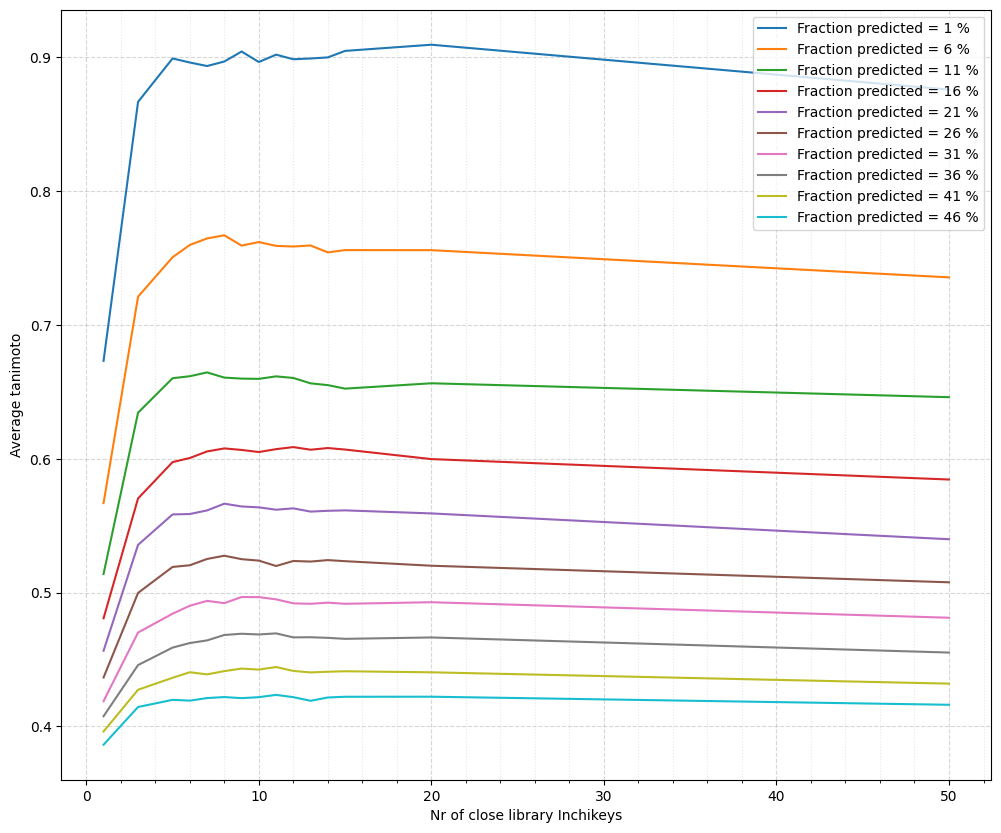

In [290]:
plt.figure(figsize = (12, 10))
for fraction_predicted in range(0, 50, 5):
    plt.plot([1,3,5,6,7,8,9,10,11,12,13,14,15,20,50], [results_average_mean_top_k_mean_highest_ms2deepscore[k][fraction_predicted] for k in results_average_mean_top_k_mean_highest_ms2deepscore.keys()], label=f"Fraction predicted = {fraction_predicted + 1} %")
plt.legend()
# plt.xlim(0,10)
ax = plt.gca()
ax.xaxis.set_minor_locator(plt.MultipleLocator(2))
ax.grid(which='both', linestyle='--', alpha=0.5)
ax.grid(which='minor', linestyle=':', alpha=0.3)
plt.ylabel("Average tanimoto")
plt.xlabel("Nr of close library Inchikeys")

# Do the same for the max ms2deepscore for top inchikeys
The resuls show a similar pattern. Somewhere beteen 5 and 10 top inchikeys is 5, which the best seems like 7. 

In [260]:
results_average_mean_top_k_max_highest_ms2deepscore = {}
for i in [1,3,5,6,7,8,9,10,11,12,13,14,15, 20, 50]:
    max_top_k = predict_using_average_max_top_k_tanimoto(i, close_tanimoto_scores)
    results_average_mean_top_k_max_highest_ms2deepscore[f"Average max top {i}"] = plot_average_per_threshold(max_top_k, tanimoto_for_prediction, pos_val_spectra, 100)


36473it [00:06, 5997.36it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 327.85it/s]
36473it [00:05, 6444.58it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 344.47it/s]
36473it [00:05, 6374.29it/s]
100%|████████████████████████████████████████████████████████

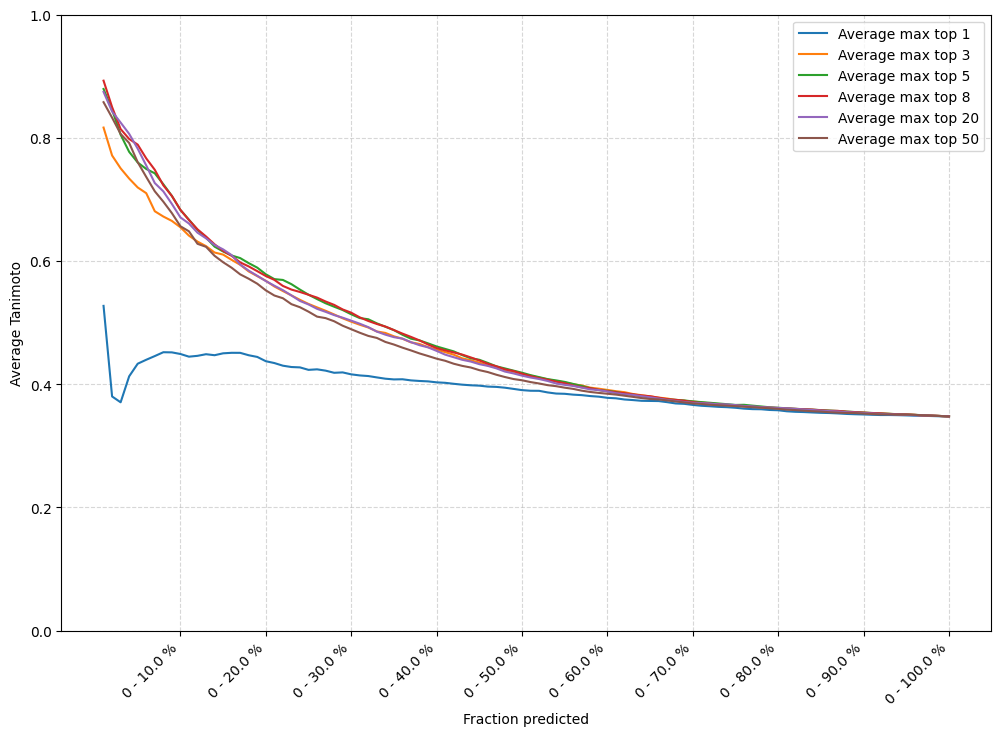

In [288]:
plt.figure(figsize=(12, 8))
# plot_comparison_plot(results_average_mean_top_k_mean_highest_ms2deepscore)
plot_comparison_plot({key: results_average_mean_top_k_max_highest_ms2deepscore[key] for key in ['Average max top 1',
                                                                                                 'Average max top 3',
                                                                                                 'Average max top 5',
                                                                                                 'Average max top 8',
                                                                                                 # 'Average mean top 9',
                                                                                                 'Average max top 20',
                                                                                                 'Average max top 50',

                                                                                     
]})

Text(0.5, 0, 'Nr of close library Inchikeys')

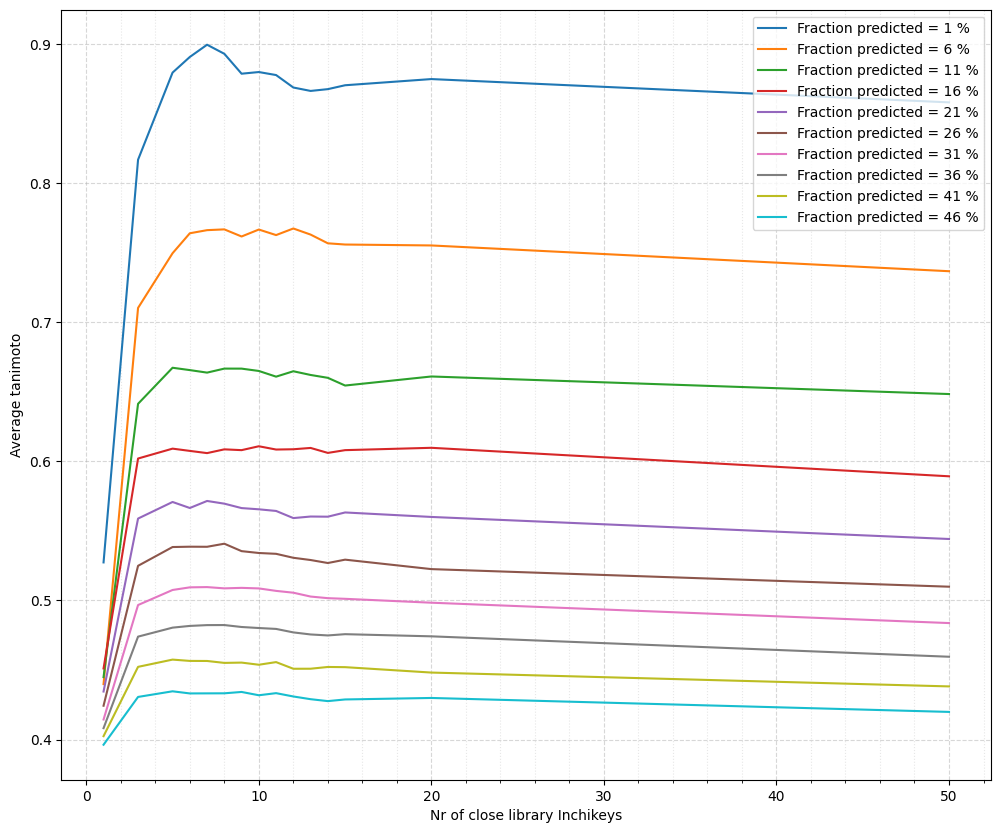

In [289]:
plt.figure(figsize = (12, 10))
for fraction_predicted in range(0, 50, 5):
    plt.plot([1,3,5,6,7,8,9,10,11,12,13,14,15,20,50], [results_average_mean_top_k_max_highest_ms2deepscore[k][fraction_predicted] for k in results_average_mean_top_k_max_highest_ms2deepscore.keys()], label=f"Fraction predicted = {fraction_predicted + 1} %")
plt.legend()
# plt.xlim(0,10)
ax = plt.gca()
ax.xaxis.set_minor_locator(plt.MultipleLocator(2))
ax.grid(which='both', linestyle='--', alpha=0.5)
ax.grid(which='minor', linestyle=':', alpha=0.3)
plt.ylabel("Average tanimoto")
plt.xlabel("Nr of close library Inchikeys")

# Other reliability prediction strategies
Using the mean of the max ms2deepscore top 8 is one of the best solutions. Below we show some interesting other variants that we tested. Which did not improve performance further. Also we test some correlations between these different approaches to get some more insights into why using this method works in the first place. 

# Threshold on precursor mz

In [271]:
average_tanimoto_precursor_mz = plot_average_per_threshold([spectrum.get('precursor_mz') for spectrum in pos_val_spectra.spectra], tanimoto_for_prediction, pos_val_spectra, 20)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 359.31it/s]


# Threshold on Embedding Evaluator
With MS2DeepScore 2.0 also an embedding evaluator was released. The goal is to predict reliability of a spectrum. Here we use this to predict reliability of the MS2DeepScore prediction. 

In [293]:
from ms2deepscore.models.load_model import load_embedding_evaluator
download_file("https://zenodo.org/records/17826815/files/embedding_evaluator.pt?download=1",
             os.path.join(folder_to_store_zenodo_files, "embedding_evaluator.pt"))
embedding_evaluator = load_embedding_evaluator(os.path.join(folder_to_store_zenodo_files, "embedding_evaluator.pt"))

In [87]:
def predict_embedding_evaluation_per_batch(
    embeddings, embedding_evaluator, batch_size: int = 500
) -> np.ndarray:
    embedding_evaluation_per_batch = []
    num_of_query_embeddings = embeddings.embeddings.shape[0]
    # loop over the batches
    for start_idx in tqdm(
        range(0, num_of_query_embeddings, batch_size),
        desc="Predicting highest ms2deepscore per batch of "
        + str(min(batch_size, num_of_query_embeddings))
        + " embeddings",
    ):
        end_idx = min(start_idx + batch_size, num_of_query_embeddings)
        selected_query_embeddings = embeddings.embeddings[start_idx:end_idx]
        evaluations_for_batch = embedding_evaluator.compute_embedding_evaluations(selected_query_embeddings)
        
        embedding_evaluation_per_batch.append(evaluations_for_batch)
    return np.concatenate(embedding_evaluation_per_batch)
embedding_evaluations = predict_embedding_evaluation_per_batch(pos_val_spectra.embeddings, embedding_evaluator)

Predicting highest ms2deepscore per batch of 500 embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:12<00:00,  5.75it/s]


In [88]:
average_tanimoto_embedding_evaluator = plot_average_per_threshold(-embedding_evaluations, tanimoto_for_prediction, pos_val_spectra, 20)

spectrum_count_per_bucket
[536, 530, 551, 680, 744, 726, 818, 819, 897, 1113, 1303, 1174, 1455, 1441, 1491, 2052, 2674, 2877, 4815, 9777]


20it [00:00, 412.67it/s]


### Combine ms2deepscore + embedding evaluator


In [89]:
average_tanimoto_ms2deepscore_min_embedding_evaluator_squarroot = plot_average_per_threshold(predicted_ms2deepscores-embedding_evaluations**0.5, tanimoto_for_prediction, pos_val_spectra, 20)

spectrum_count_per_bucket
[540, 715, 789, 1047, 1063, 1234, 1065, 1194, 1563, 1440, 1682, 1529, 1909, 1786, 1906, 2066, 2199, 2780, 2927, 7039]


20it [00:00, 388.93it/s]


# Use uniqueness in library
The average MS2DeepScore for top 10, is strongly influenced by the tanimoto score for the top 10. If there are no highly similar metabolites in the library (so low tanimoto scores), the MS2DeepScores will probably also be very low. So low reliability will be predicted. To get insight in if this is a good thing and if this is a large part of the ability to predict reliability, we will test this as well. 

In [105]:
average_top_10_tanimoto = []
for inchikey in tqdm(predicted_inchikeys):
    tanimoto_scores = np.array(list(top_k_tanimoto_scores.select_top_k_inchikeys_and_scores(inchikey).values()))
    average_top_10_tanimoto.append(np.sort(tanimoto_scores)[-10:].mean())

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:18<00:00, 2009.90it/s]


In [106]:
average_tanimoto_average_top_10_tanimoto = plot_average_per_threshold(average_top_10_tanimoto, tanimoto_for_prediction, pos_val_spectra, 20)

spectrum_count_per_bucket
[340, 1121, 1131, 1326, 1627, 1420, 1709, 1853, 1423, 1591, 1324, 1352, 1435, 1161, 1371, 1613, 1657, 2098, 3280, 7641]


20it [00:00, 369.63it/s]


In [ ]:
precursor_mz = [spectrum.get('precursor_mz') for spectrum in pos_val_spectra.spectra]

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 349.42it/s]


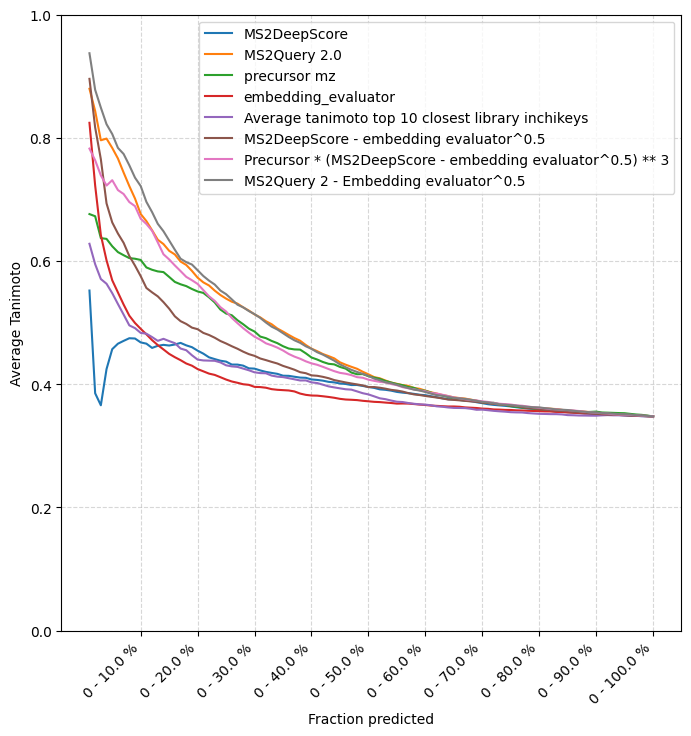

In [ ]:
plt.figure(figsize=(8, 8))
plot_comparison_plot({
    # "MS2Query 1.0": mean_per_fraction_ms2query,
    # "ms2deepscore (reliability = mean ms2deepscore top 10)": mean_per_fraction_average_mean_top_tanimoto,
    "MS2DeepScore": mean_per_ms2deepscore,
    # "Best possible reliabitly prediction": mean_per_fraction_best_possible_ranker,
    "MS2Query 2.0": plot_average_per_threshold(threshold_score_average_max_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 100),
    "precursor mz": plot_average_per_threshold([spectrum.get('precursor_mz') for spectrum in pos_val_spectra.spectra], tanimoto_for_prediction, pos_val_spectra, 100),
    "embedding_evaluator": plot_average_per_threshold(-embedding_evaluations, tanimoto_for_prediction, pos_val_spectra, 100),
    "Average tanimoto top 10 closest library inchikeys": plot_average_per_threshold(average_top_10_tanimoto, tanimoto_for_prediction, pos_val_spectra, 100),
    "MS2DeepScore - embedding evaluator^0.5": plot_average_per_threshold(predicted_ms2deepscores-embedding_evaluations**0.5, tanimoto_for_prediction, pos_val_spectra, 100),
    "Precursor * (MS2DeepScore - embedding evaluator^0.5) ** 3": plot_average_per_threshold(np.array(precursor_mz) * (np.array(predicted_ms2deepscores) - embedding_evaluations**0.5)**3, tanimoto_for_prediction, pos_val_spectra, 100),
    "MS2Query 2 - Embedding evaluator^0.5": plot_average_per_threshold(threshold_score_average_max_top_tanimoto - embedding_evaluations** 0.5, tanimoto_for_prediction, pos_val_spectra, 100),
                     })

# Explore the reason MS2Query 2 works
Above we have explored all these different methods for predicting reliability. We want to explore a bit more what is going on under the hood. Is the power taking the average over multiple scores? Or is the MS2Query 2 method mostly guided by how common a library molecule is, so more a mean of testing if the prediction was well in the training distribution. Here we do some correlation plots to get some insights in this. 

In [ ]:
!pip install seaborn
import seaborn as sns


In [209]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_pairplot_with_color_gradient(df):
    cmap = 'viridis'
    hue_col = "Real Tanimoto score"
    plot_vars = ["precursor mz", "Average MS2DeepScore top 10", 
                 "Average Tanimoto score top 10", "embedding evaluator", "ms2deepscore"]
    
    norm = plt.Normalize(df[hue_col].min(), df[hue_col].max())
    colors = plt.cm.viridis(norm(df[hue_col]))
    
    def offdiag(x, y, **kwargs):
        c = colors[x.index]  # align colors to current subset index
        m, b = np.polyfit(x, y, 1)
        plt.scatter(x, y, alpha=0.3, c=c, s=1)
        x_sorted = np.sort(x)
        plt.plot(x_sorted, m * x_sorted + b, color='#E8A838', linewidth=1.5, linestyle='--')
    
    def diag(x, **kwargs):
        ax = plt.gca()
        
        # Compute KDE
        kde = gaussian_kde(x.dropna())
        x_range = np.linspace(x.min(), x.max(), 300)
        density = kde(x_range)
        
        # Normalize so the peak always hits the same height
        density_scaled = density / density.max()
        
        ax.fill_between(x_range, density_scaled, alpha=0.4, color='steelblue')
        ax.plot(x_range, density_scaled, color='steelblue', linewidth=1.2)
        ax.set_ylim(0, 1.15)  # consistent y-axis across all diagonal cells
    
    g = sns.PairGrid(df, vars=plot_vars)
    g.map_offdiag(offdiag)
    g.map_diag(diag)
    g.figure.subplots_adjust(hspace=-0.5, wspace=0.1)
    
    # Smaller tick and axis labels to prevent overlap
    for ax in g.axes.flatten():
        ax.set_box_aspect(1)
        ax.tick_params(labelsize=7)
        ax.xaxis.label.set_size(8)
        ax.yaxis.label.set_size(8)
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = g.figure.colorbar(sm, ax=g.axes, label=hue_col, shrink=0.6, pad=0.02)
    
    plt.show()


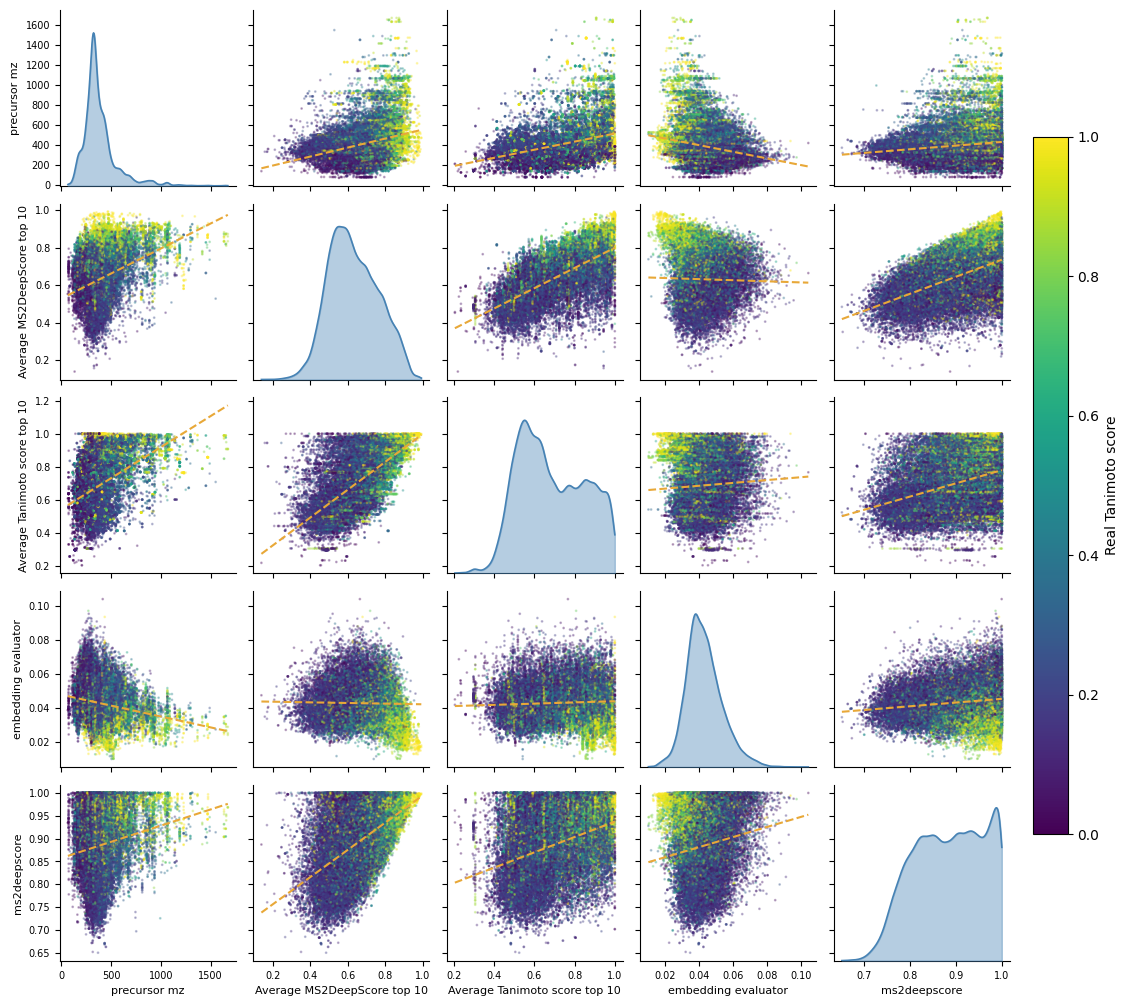

In [284]:
reliability_predictions_all_spectra = pd.DataFrame({
    "precursor mz": precursor_mz,
    "Average MS2DeepScore top 10": threshold_score_average_max_top_tanimoto,
    "Real Tanimoto score": tanimoto_for_prediction,
    "Average Tanimoto score top 10": average_top_10_tanimoto, 
    "embedding evaluator": embedding_evaluations,
    "ms2deepscore": predicted_ms2deepscores,
})
plot_pairplot_with_color_gradient(reliability_predictions_all_spectra)

# Plot one spectrum per inchikey
Above each validation spectrum is plotted. This makes the overview a bit cluttered, since these are more than 50.000 spectra. But also it might give a bit too much weight to inchikeys with a lot of spectra. So below we randomly select one validation spectrum per unique inchikey. 

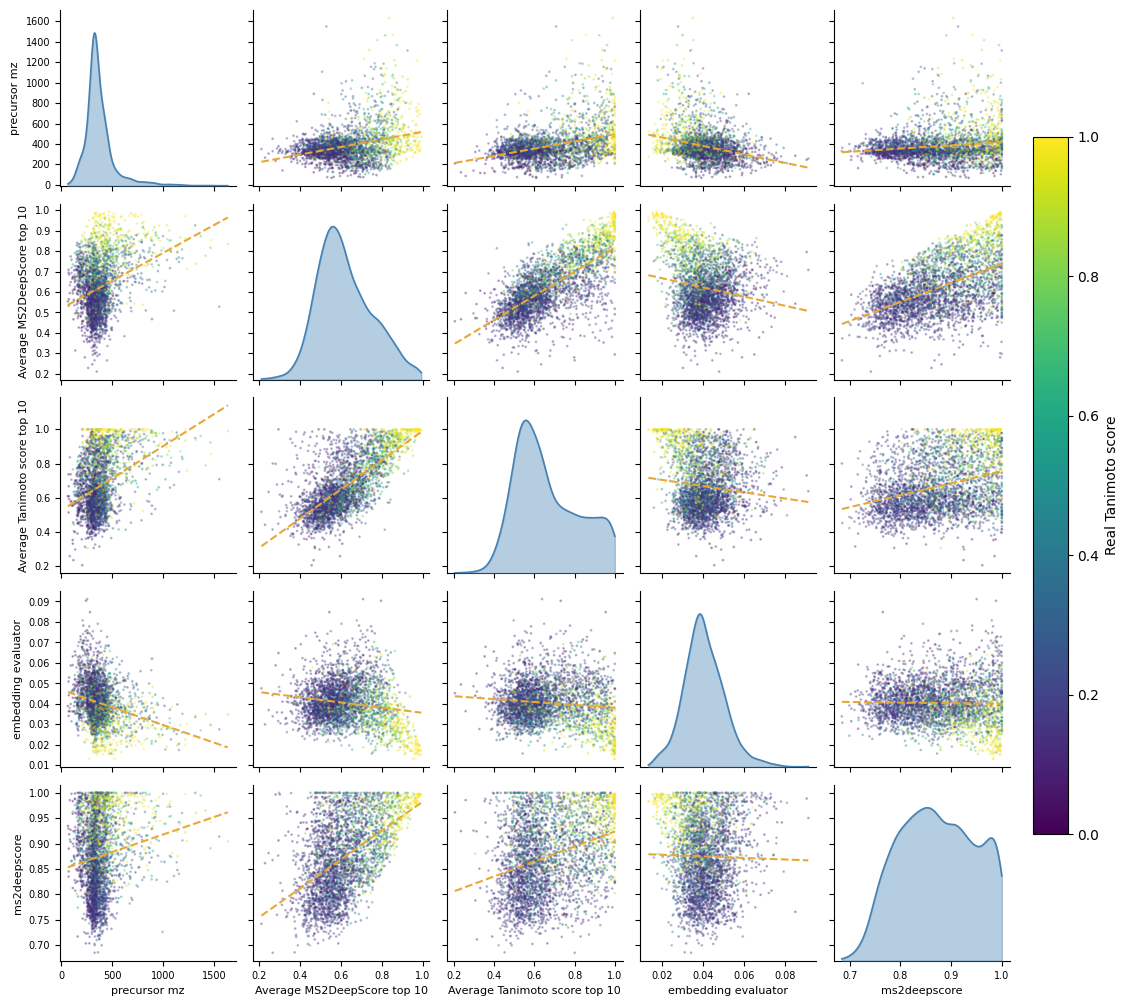

In [211]:
import pandas as pd
import random

indexes_of_spectra_per_inchikey = []
for inchikey, spectrum_indexes in pos_val_spectra.spectrum_indices_per_inchikey.items():
    indexes_of_spectra_per_inchikey.append(random.choice(spectrum_indexes))
    
reliability_predictions_one_specrum_per_inchikey = pd.DataFrame({
    "precursor mz": np.array(precursor_mz)[indexes_of_spectra_per_inchikey],
    "Average MS2DeepScore top 10": np.array(threshold_score_average_max_top_tanimoto)[indexes_of_spectra_per_inchikey],
    "Real Tanimoto score": np.array(tanimoto_for_prediction)[indexes_of_spectra_per_inchikey],
    "Average Tanimoto score top 10": np.array(average_top_10_tanimoto)[indexes_of_spectra_per_inchikey],
    "embedding evaluator": np.array(embedding_evaluations)[indexes_of_spectra_per_inchikey],
    "ms2deepscore": np.array(predicted_ms2deepscores)[indexes_of_spectra_per_inchikey]
})
plot_pairplot_with_color_gradient(reliability_predictions_one_specrum_per_inchikey)

#

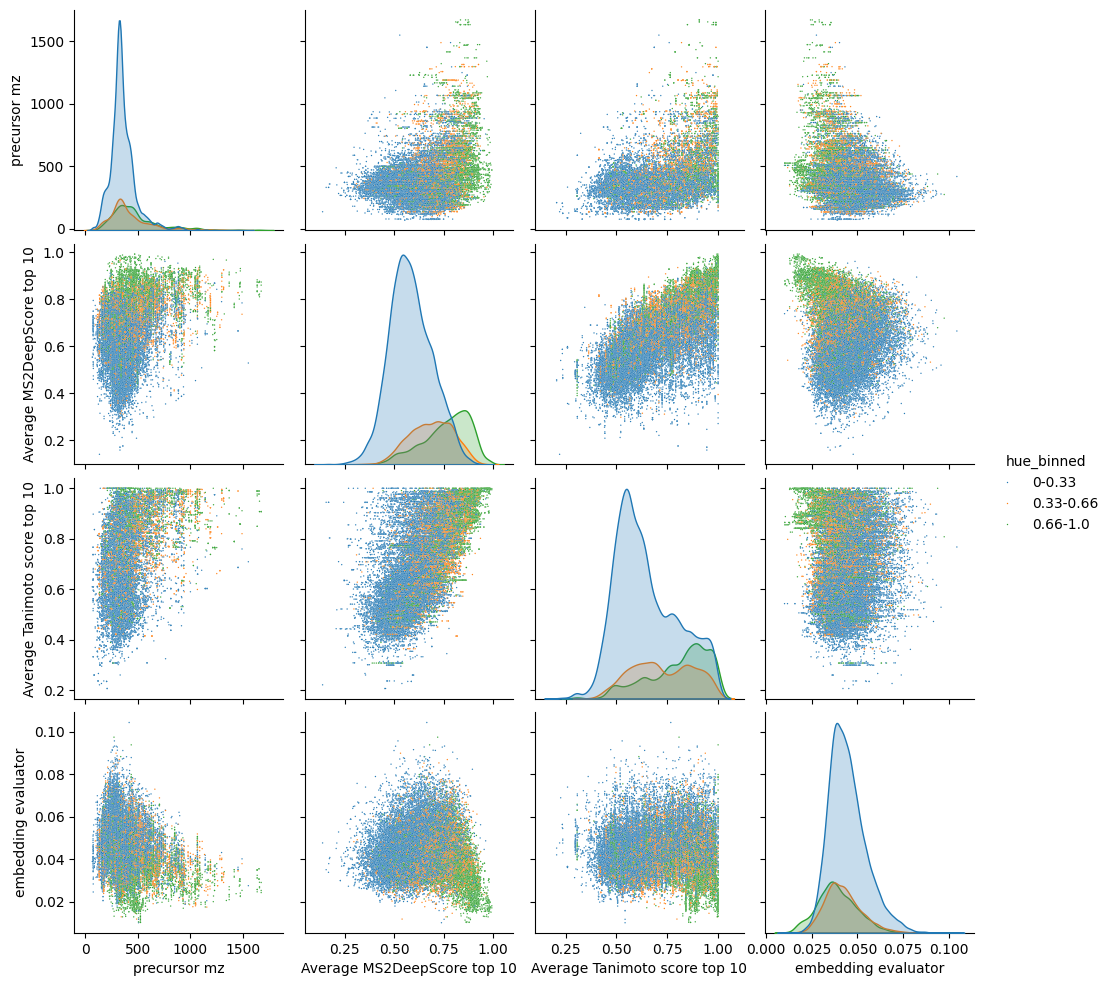

In [286]:
reliability_predictions_all_spectra["hue_binned"] = pd.cut(reliability_predictions_all_spectra["Real Tanimoto score"], bins=3, labels=["0-0.33", "0.33-0.66", "0.66-1.0"])
sns.pairplot(reliability_predictions_all_spectra, kind="scatter", hue="hue_binned", vars = ["precursor mz", "Average MS2DeepScore top 10", "Average Tanimoto score top 10", "embedding evaluator"],
             # diag_kind="hist", 
             plot_kws={"alpha": 1.0, "rasterized":True, "s":1})

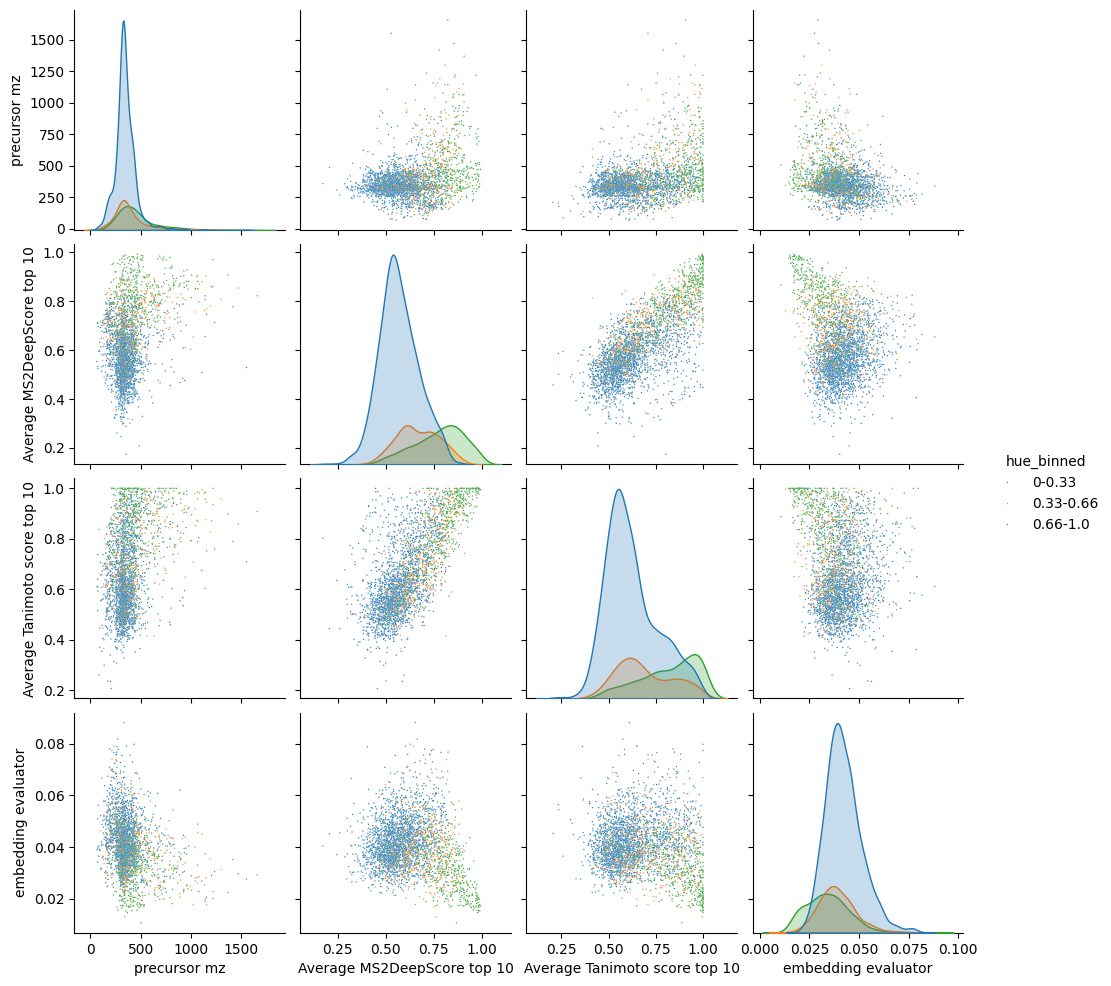

In [287]:
reliability_predictions_one_specrum_per_inchikey["hue_binned"] = pd.cut(reliability_predictions_one_specrum_per_inchikey["Real Tanimoto score"], bins=3, labels=["0-0.33", "0.33-0.66", "0.66-1.0"])
sns.pairplot(reliability_predictions_one_specrum_per_inchikey, kind="scatter", hue="hue_binned", vars = ["precursor mz", "Average MS2DeepScore top 10", "Average Tanimoto score top 10", "embedding evaluator"],
             # diag_kind="hist", 
             plot_kws={"alpha": 1.0, "rasterized":True, "s":1})

# Split on Inchikey instead of spectra
In the plots showing the average tanimioto score for different thresholds. The fraction predicted is the fraction of the ~50000 validation spectra. However, we could also choose to show the fraction of ~3000 unique inchikeys for which at least one prediction is made. I am not sure what the best way is to test this. Per Inchikey makes sense, since the y axis is already the average tanimoto score per inchikey, so that would make it match. But just splitting on number of spectra also makes more sense to me. 
Another option could be is to just randomly sample 1 unique spectrum per inchikey. This would make everything a lot more intuitive, but you are discarding some information. We could even consider running random sampling 100 times, to get the ranking done and maybe plot the average with some standard deviation. This has not yet been tried. 

In [80]:
def plot_average_per_threshold_inchikeys(predicted_scores, tanimoto_for_predictions, val_spectra, n_of_buckets):
    buckets = split_on_inchikey_fractions(predicted_scores,n_of_buckets, val_spectra, )
    mean_per_fraction = []
    selected_indexes = set()
    for indexes_in_bucket in tqdm(buckets):
        selected_indexes.update(set(indexes_in_bucket.tolist()))
        average_scores_per_inchikey = get_average_tanimoto_per_inchikey(val_spectra, tanimoto_for_predictions, selected_indexes)
        mean = sum(average_scores_per_inchikey)/len(average_scores_per_inchikey)
        mean_per_fraction.append(mean)
    return mean_per_fraction

def create_values_violin_plot_inchikey_fractions(predicted_scores, val_spectra, tanimoto_for_predictions, n_buckets):
    """The predictions are ranked based on the predicted scores, and are split in different groups from high to low, 
    for each group the average tanimoto per inchikey is computed."""
    tanimoto_per_bucket = []
    ranked_indexes_per_bucket = split_on_inchikey_fractions(predicted_scores, n_buckets, val_spectra)
    for indexes_in_bucket in ranked_indexes_per_bucket: 
        average_tanimoto_per_inchikey = get_average_tanimoto_per_inchikey(val_spectra, tanimoto_for_predictions, indexes_in_bucket)
        tanimoto_per_bucket.append(average_tanimoto_per_inchikey)
    return tanimoto_per_bucket

    
def split_on_inchikey_fractions(threshold_values, n_buckets, val_spectra):
    threshold_values = np.array(threshold_values)
    
    highest_score_per_inchikey = np.array([
        threshold_values[list(spectrum_indices)].max()
        for spectrum_indices in val_spectra.spectrum_indices_per_inchikey.values()
    ])
    
    # Get the score cutoffs that split inchikeys into equal-sized groups
    percentiles = np.linspace(0, 100, n_buckets + 1)
    cutoffs = np.percentile(highest_score_per_inchikey, percentiles)
    # Assign each threshold_value to a bucket based on those cutoffs
    bucket_indices = np.digitize(threshold_values, cutoffs[1:-1], right=False)
    buckets = [np.where(bucket_indices == i)[0] for i in range(n_buckets)]
    print("spectrum_count_per_bucket")
    print([len(bucket) for bucket in reversed(buckets)])
    return reversed(buckets)

spectrum_count_per_bucket
[1482, 1996, 2657, 2609, 3307, 3121, 3613, 3710, 4327, 9651]


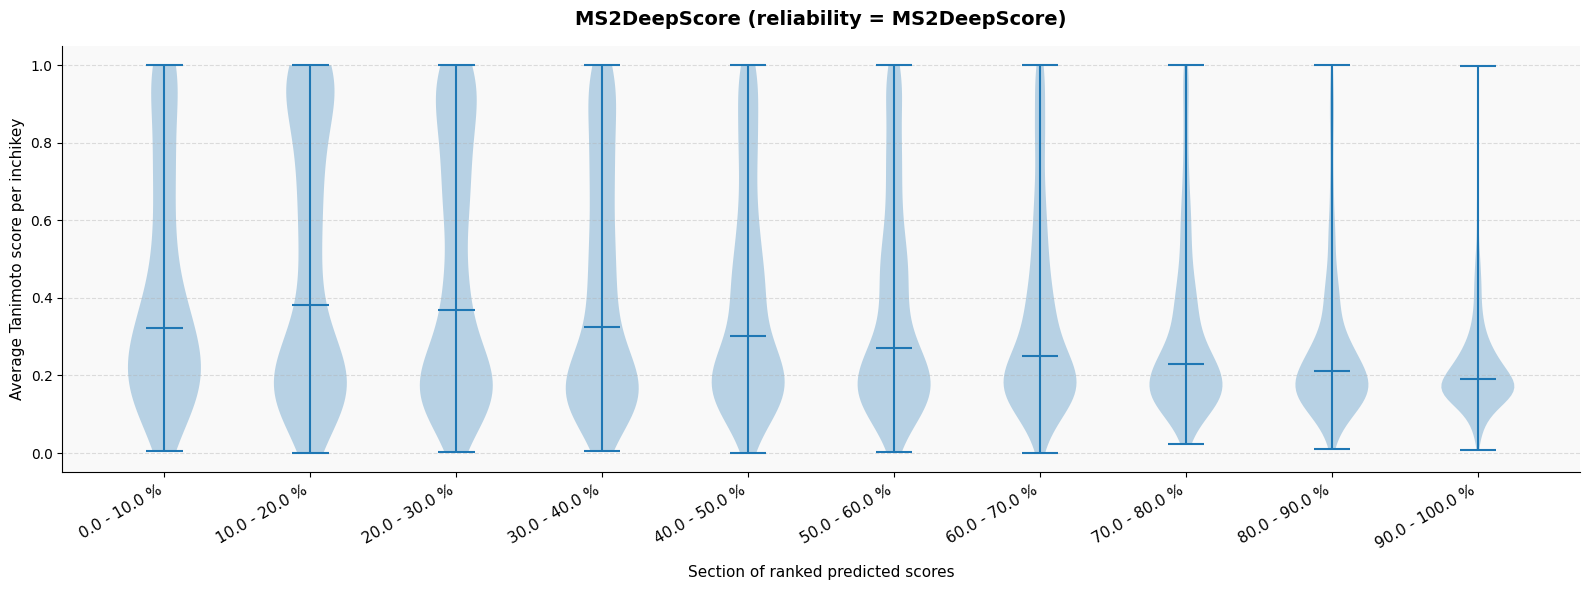

In [246]:
plot_violins(create_values_violin_plot_inchikey_fractions(predicted_ms2deepscores, pos_val_spectra, tanimoto_for_prediction, 10), title="MS2DeepScore (reliability = MS2DeepScore)")

spectrum_count_per_bucket
[1852, 2410, 3084, 3257, 2763, 2726, 2172, 2796, 3635, 11778]


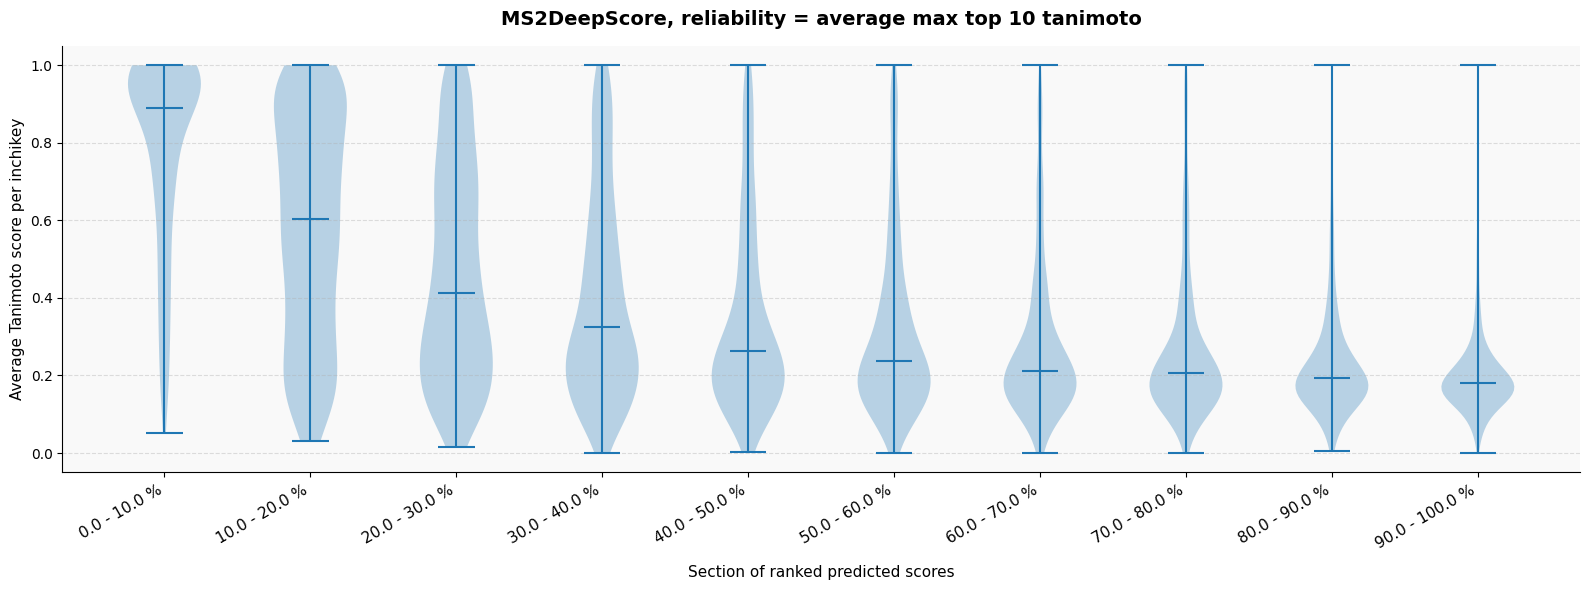

In [247]:
plot_violins(create_values_violin_plot_inchikey_fractions(threshold_score_average_max_top_tanimoto, pos_val_spectra, tanimoto_for_prediction, 10), title="MS2DeepScore, reliability = average max top 10 tanimoto")

spectrum_count_per_bucket
[271, 0, 2339, 1245, 963, 1159, 1075, 1207, 507, 0, 2552, 1661, 458, 0, 4828, 1748, 1709, 1318, 3959, 9474]


20it [00:00, 403.65it/s]


spectrum_count_per_bucket
[485, 1367, 1238, 1172, 1574, 1510, 1526, 1731, 1447, 1316, 1313, 1413, 1112, 1060, 1350, 1446, 1674, 1961, 2940, 8838]


20it [00:00, 382.05it/s]


spectrum_count_per_bucket
[571, 911, 853, 1143, 1232, 1425, 1240, 1369, 1501, 1806, 1605, 1516, 1951, 1662, 1851, 1859, 1988, 2339, 2966, 6685]


20it [00:00, 385.68it/s]


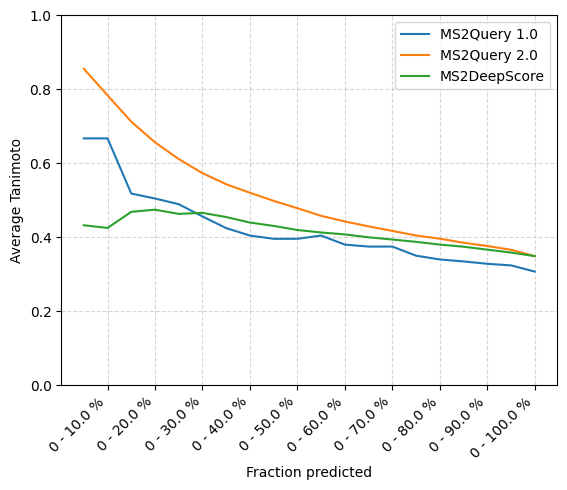

In [267]:
plot_comparison_plot({"MS2Query 1.0": plot_average_per_threshold_inchikeys(predicted_score, tanimoto_for_prediction_ms2query, pos_val_spectra, 20),
                     "MS2Query 2.0": plot_average_per_threshold_inchikeys(threshold_score_average_max_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 20),
                     "MS2DeepScore": plot_average_per_threshold_inchikeys(predicted_ms2deepscores, tanimoto_for_prediction, pos_val_spectra, 20)})

spectrum_count_per_bucket
[571, 911, 853, 1143, 1232, 1425, 1240, 1369, 1501, 1806, 1605, 1516, 1951, 1662, 1851, 1859, 1988, 2339, 2966, 6685]


20it [00:00, 366.84it/s]


spectrum_count_per_bucket
[485, 1367, 1238, 1172, 1574, 1510, 1526, 1731, 1447, 1316, 1313, 1413, 1112, 1060, 1350, 1446, 1674, 1961, 2940, 8838]


20it [00:00, 369.72it/s]


spectrum_count_per_bucket
[1590, 2306, 2134, 2247, 1683, 1694, 1800, 1321, 1800, 1545, 1271, 1621, 1379, 1358, 1754, 1792, 1932, 2411, 2358, 2477]


...

20it [00:00, 385.13it/s]


spectrum_count_per_bucket
[540, 715, 789, 1047, 1063, 1234, 1065, 1194, 1563, 1440, 1682, 1529, 1909, 1786, 1906, 2066, 2199, 2780, 2927, 7039]


20it [00:00, 382.48it/s]


spectrum_count_per_bucket
[1329, 1563, 1463, 1278, 1300, 1181, 1190, 1065, 1179, 1304, 1412, 1404, 1483, 1913, 1733, 1833, 1780, 2436, 3732, 5895]


20it [00:00, 377.91it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 329.01it/s]


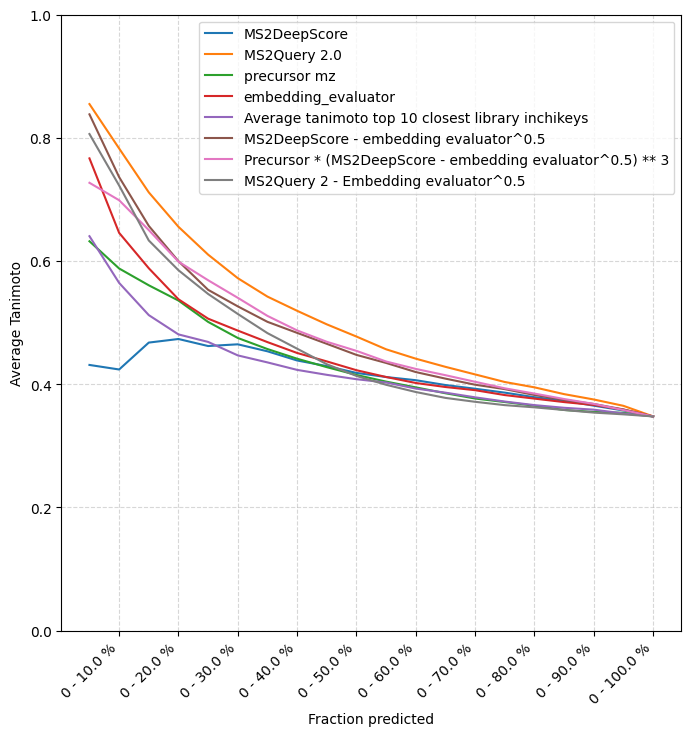

In [280]:
plt.figure(figsize=(8, 8))
plot_comparison_plot({
    # "MS2Query 1.0":  plot_average_per_threshold_inchikeys(predicted_score, tanimoto_for_prediction_ms2query, pos_val_spectra, 20),
    # "ms2deepscore (reliability = mean ms2deepscore top 10)": mean_per_fraction_average_mean_top_tanimoto,
    "MS2DeepScore":  plot_average_per_threshold_inchikeys(predicted_ms2deepscores, tanimoto_for_prediction, pos_val_spectra, 20),
    # "Best possible reliabitly prediction": mean_per_fraction_best_possible_ranker,
    "MS2Query 2.0": plot_average_per_threshold_inchikeys(threshold_score_average_max_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 20),
    "precursor mz": plot_average_per_threshold_inchikeys([spectrum.get('precursor_mz') for spectrum in pos_val_spectra.spectra], tanimoto_for_prediction, pos_val_spectra, 20),
    "embedding_evaluator": plot_average_per_threshold_inchikeys(-embedding_evaluations, tanimoto_for_prediction, pos_val_spectra, 20),
    "Average tanimoto top 10 closest library inchikeys": plot_average_per_threshold_inchikeys(average_top_10_tanimoto, tanimoto_for_prediction, pos_val_spectra, 20),
    "MS2DeepScore - embedding evaluator^0.5": plot_average_per_threshold_inchikeys(predicted_ms2deepscores-embedding_evaluations**0.5, tanimoto_for_prediction, pos_val_spectra, 20),
    "Precursor * (MS2DeepScore - embedding evaluator^0.5) ** 3": plot_average_per_threshold_inchikeys(np.array(precursor_mz) * (np.array(predicted_ms2deepscores) - embedding_evaluations**0.5)**3, tanimoto_for_prediction, pos_val_spectra, 20),
    "MS2Query 2 - Embedding evaluator^0.5": plot_average_per_threshold(threshold_score_average_max_top_tanimoto - embedding_evaluations** 0.5, tanimoto_for_prediction, pos_val_spectra, 20),
                     })

# Negative ionization mode predictions
Below we will repeat the most important analysis for negative ionization mode as well. If you want to redo all analysis you can of course copy the notebook change pos to neg at the top and get all optimization results.

### Check the top of the notebook to get the negative ionization mode spectra with embeddings. 

In [312]:
print(neg_val_spectra)
print(neg_train_spectra)

15967 spectra for 1614 inchikeys with embeddings
283790 spectra for 29806 inchikeys with embeddings


In [ ]:
from ms2query.benchmarking.Fingerprints import Fingerprints
from ms2query.benchmarking.TopKTanimotoScores import TopKTanimotoScores
from ms2query.benchmarking.reference_methods.predict_top_k_ms2deepscore import select_inchikeys_with_highest_ms2deepscore
from ms2query.benchmarking.reference_methods.MS2DeepScoresForTopInChikeys import calculate_MS2DeepScoresForTopKInChikeys

neg_val_fingerprints = Fingerprints.from_spectrum_set(neg_val_spectra, "daylight", 4096)
neg_train_fingerprints = Fingerprints.from_spectrum_set(neg_train_spectra, "daylight", 4096)

all_neg_fingerprints = Fingerprints.combine_fingerprints(neg_val_fingerprints, neg_train_fingerprints)

neg_neg_top_k_tanimoto_scores = TopKTanimotoScores.calculate_from_fingerprints(
        neg_train_fingerprints,
        neg_train_fingerprints, k=8,)

neg_neg_inchikeys_with_highest_ms2deepscores = select_inchikeys_with_highest_ms2deepscore(
        neg_val_spectra, neg_train_spectra, nr_of_inchikeys_to_select=1, batch_size=1000,)
neg_neg_close_tanimoto_scores = calculate_MS2DeepScoresForTopKInChikeys(neg_train_spectra, neg_val_spectra, neg_neg_top_k_tanimoto_scores, neg_neg_inchikeys_with_highest_ms2deepscores)


Get most common inchi per inchikey: 100%|███████████████████████████████████████████████████| 1614/1614 [00:00<00:00, 19467.33it/s]
Adding fingerprints to Inchikeys: 1614it [00:05, 274.31it/s]
Get most common inchi per inchikey: 100%|█████████████████████████████████████████████████| 29806/29806 [00:01<00:00, 28554.39it/s]
Adding fingerprints to Inchikeys: 29806it [01:49, 273.25it/s]
Selecting highest ms2deepscore: 16it [01:09,  4.34s/it]                                                                            
Calculating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15967/15967 [00:12<00:00, 1242.32it/s]


In [322]:
import os
import pickle
intermediates_folder = "./neg_neg_intermediate"
os.makedirs(intermediates_folder, exist_ok=True)
with open(os.path.join(intermediates_folder, "top_1_highest_ms2deepscore_with_8_top_inchikeys.pickle"), "wb") as handle:
    pickle.dump(neg_neg_close_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(intermediates_folder, "neg_val_spectra_with_embeddings.pickle"), "wb") as handle:
    pickle.dump(neg_val_spectra, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(intermediates_folder, "neg_val_and_train_fingerprints.pickle"), "wb") as handle:
    pickle.dump(all_neg_fingerprints, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(intermediates_folder, "top_k_tanimoto_scores.pickle"), "wb") as handle:
    pickle.dump(neg_neg_top_k_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Optional load in intermediates

In [62]:
import pickle
import os
intermediates_folder = "./neg_neg_intermediate"

with open(os.path.join(intermediates_folder, "top_1_highest_ms2deepscore_with_8_top_inchikeys.pickle"), "rb") as handle:
    neg_neg_close_tanimoto_scores = pickle.load(handle)
with open(os.path.join(intermediates_folder, "neg_val_spectra_with_embeddings.pickle"), "rb") as handle:
    neg_val_spectra = pickle.load(handle)
with open(os.path.join(intermediates_folder, "neg_val_and_train_fingerprints.pickle"), "rb") as handle:
    all_neg_fingerprints = pickle.load(handle)
with open(os.path.join(intermediates_folder, "top_k_tanimoto_scores.pickle"), "rb") as handle:
    neg_neg_top_k_tanimoto_scores = pickle.load(handle)

# Plot results

In [ ]:
from ms2query.benchmarking.reference_methods.predict_top_k_ms2deepscore import predict_top_k_ms2deepscores

indexes, ms2deepscores = predict_top_k_ms2deepscores(neg_train_spectra.embeddings, neg_val_spectra.embeddings)
neg_predicted_inchikeys_ms2deepscore = [neg_train_spectra.spectra[int(index)].get("inchikey")[:14] for index in indexes]
neg_neg_tanimoto_for_prediction_ms2deepscore = get_prediction_tanimoto(neg_predicted_inchikeys_ms2deepscore, neg_val_spectra, all_neg_fingerprints)

In [69]:
threshold_scores_ms2query_2 = predict_using_average_max_top_k_tanimoto(8, neg_neg_close_tanimoto_scores)
neg_neg_predicted_inchikeys = [list(query.keys())[0] for query in neg_neg_close_tanimoto_scores]
neg_neg_tanimoto_for_prediction = get_prediction_tanimoto(neg_neg_predicted_inchikeys, neg_val_spectra, all_neg_fingerprints)

15967it [00:00, 63652.20it/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15967/15967 [00:00<00:00, 26078.85it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 368.89it/s]


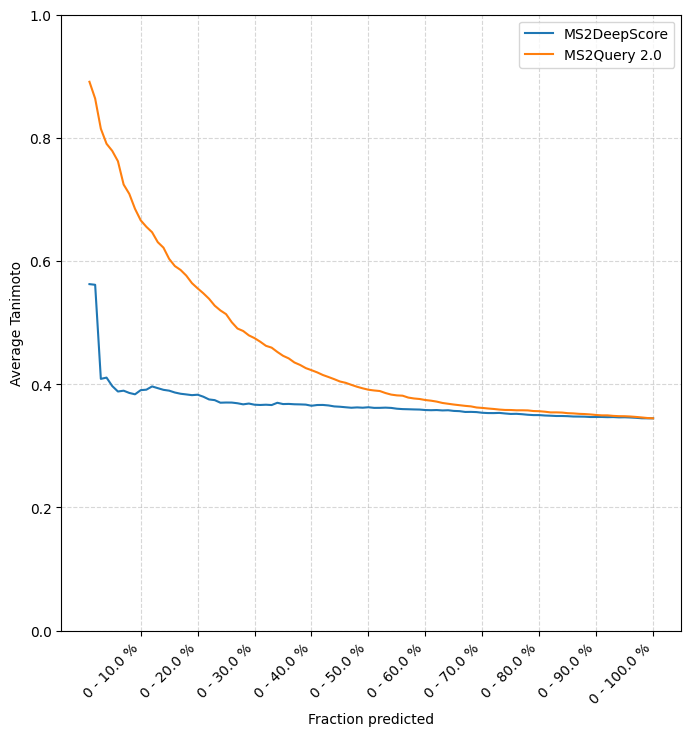

In [374]:
plt.figure(figsize=(8, 8))
plot_comparison_plot({
    "MS2DeepScore":  plot_average_per_threshold(ms2deepscores.squeeze(), neg_neg_tanimoto_for_prediction_ms2deepscore, neg_val_spectra, 100),
    "MS2Query 2.0": plot_average_per_threshold(threshold_scores_ms2query_2, neg_neg_tanimoto_for_prediction, neg_val_spectra, 100),
})

# Search across ionization modes 
MS2DeepScore 2.0 allows for cross ionization mode predictions. Below we test the prediction accuracy when allowing for this cross ionization mode searching. 

In [376]:
neg_train_spectra

AnnotatedSpectrumSet(nr_of_spectra = 283790,nr_of_unique_inchikeys = 29806, has_embeddings=True)

In [377]:
combined_train_spectra = neg_train_spectra + pos_train_spectra


In [378]:
print(combined_train_spectra)

915669 spectra for 60884 inchikeys with embeddings


In [379]:
combined_train_fingerprints = Fingerprints.from_spectrum_set(combined_train_spectra, "daylight", 4096)

Get most common inchi per inchikey: 100%|█████████████████████████████████████████████████| 60884/60884 [00:02<00:00, 21996.65it/s]
Adding fingerprints to Inchikeys: 60884it [04:14, 239.39it/s]


In [ ]:
pos_neg_top_k_tanimoto_scores = TopKTanimotoScores.calculate_from_fingerprints(
        combined_train_fingerprints,
        combined_train_fingerprints, k=8,)

In [382]:
neg_pos_inchikeys_with_highest_ms2deepscores = select_inchikeys_with_highest_ms2deepscore(
        neg_val_spectra, combined_train_spectra, nr_of_inchikeys_to_select=1, batch_size=1000,)
neg_pos_close_tanimoto_scores = calculate_MS2DeepScoresForTopKInChikeys(combined_train_spectra, neg_val_spectra, pos_neg_top_k_tanimoto_scores, neg_pos_inchikeys_with_highest_ms2deepscores)

Selecting highest ms2deepscore: 16it [04:03, 15.20s/it]                                                                            
Calculating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15967/15967 [00:18<00:00, 877.56it/s]


In [389]:
pos_neg_inchikeys_with_highest_ms2deepscores = select_inchikeys_with_highest_ms2deepscore(
        pos_val_spectra, combined_train_spectra, nr_of_inchikeys_to_select=1, batch_size=1000,)
pos_neg_close_tanimoto_scores = calculate_MS2DeepScoresForTopKInChikeys(combined_train_spectra, pos_val_spectra, pos_neg_top_k_tanimoto_scores, pos_neg_inchikeys_with_highest_ms2deepscores)

Selecting highest ms2deepscore: 37it [09:12, 14.93s/it]                                                                            
Calculating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:44<00:00, 823.63it/s]


In [397]:
neg_val_all_train_fingerprints = Fingerprints.combine_fingerprints(combined_train_fingerprints, neg_val_fingerprints)
pos_val_fingerprints = Fingerprints.from_spectrum_set(pos_val_spectra, "daylight", 4096)
all_fingerprints = Fingerprints.combine_fingerprints(neg_val_all_train_fingerprints, pos_val_fingerprints)

In [398]:
import os
import pickle
intermediates_folder = "./cross_ionmode_intermediate"
os.makedirs(intermediates_folder, exist_ok=True)
with open(os.path.join(intermediates_folder, "neg_top_1_highest_ms2deepscore_with_8_top_inchikeys.pickle"), "wb") as handle:
    pickle.dump(neg_pos_close_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(intermediates_folder, "pos_top_1_highest_ms2deepscore_with_8_top_inchikeys.pickle"), "wb") as handle:
    pickle.dump(pos_neg_close_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(intermediates_folder, "all_fingerprints.pickle"), "wb") as handle:
    pickle.dump(all_fingerprints, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(intermediates_folder, "top_k_tanimoto_scores.pickle"), "wb") as handle:
    pickle.dump(pos_neg_top_k_tanimoto_scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [385]:
neg_pos_threshold_scores_ms2query_2 = predict_using_average_max_top_k_tanimoto(8, neg_pos_close_tanimoto_scores)
neg_pos_tanimoto_for_prediction = get_prediction_tanimoto([list(query.keys())[0] for query in neg_pos_close_tanimoto_scores], neg_val_spectra, neg_val_all_train_fingerprints)

15967it [00:00, 66007.86it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 15967/15967 [00:01<00:00, 15383.38it/s]


In [392]:
pos_val_fingerprints = Fingerprints.from_spectrum_set(pos_val_spectra, "daylight", 4096)
pos_val_all_train_fingerprints = Fingerprints.combine_fingerprints(combined_train_fingerprints, pos_val_fingerprints)

Get most common inchi per inchikey: 100%|███████████████████████████████████████████████████| 3119/3119 [00:00<00:00, 21231.00it/s]
Adding fingerprints to Inchikeys: 3119it [02:15, 23.09it/s] 


In [393]:
pos_neg_threshold_scores_ms2query_2 = predict_using_average_max_top_k_tanimoto(8, pos_neg_close_tanimoto_scores)
pos_neg_tanimoto_for_prediction = get_prediction_tanimoto([list(query.keys())[0] for query in pos_neg_close_tanimoto_scores], pos_val_spectra, pos_val_all_train_fingerprints)

36473it [00:00, 63752.37it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:01<00:00, 23028.36it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 308.19it/s]


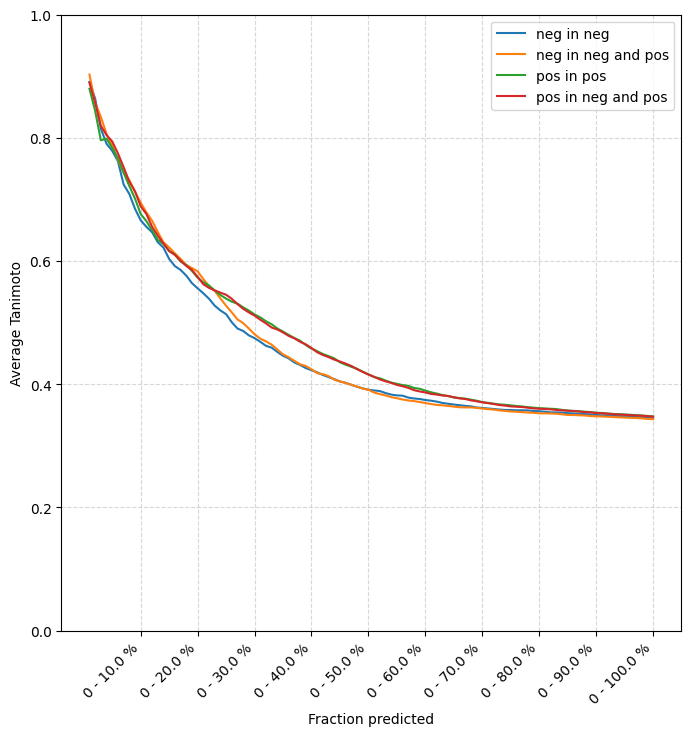

In [394]:
plt.figure(figsize=(8, 8))
plot_comparison_plot({
    "neg in neg": plot_average_per_threshold(threshold_scores_ms2query_2, neg_neg_tanimoto_for_prediction, neg_val_spectra, 100),
    "neg in neg and pos": plot_average_per_threshold(neg_pos_threshold_scores_ms2query_2, neg_pos_tanimoto_for_prediction, neg_val_spectra, 100),
    "pos in pos": plot_average_per_threshold(threshold_score_average_max_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 100),
    "pos in neg and pos": plot_average_per_threshold(pos_neg_threshold_scores_ms2query_2, pos_neg_tanimoto_for_prediction, pos_val_spectra, 100),
})

spectrum_count_per_bucket
[286, 413, 478, 504, 444, 562, 526, 495, 516, 474, 495, 482, 510, 564, 632, 516, 839, 1193, 1647, 4391]


20it [00:00, 612.79it/s]


spectrum_count_per_bucket
[277, 412, 560, 561, 430, 586, 615, 480, 446, 417, 514, 438, 518, 529, 575, 624, 689, 1087, 1981, 4228]


20it [00:00, 678.64it/s]


spectrum_count_per_bucket
[485, 1367, 1238, 1172, 1574, 1510, 1526, 1731, 1447, 1316, 1313, 1413, 1112, 1060, 1350, 1446, 1674, 1961, 2940, 8838]


20it [00:00, 338.39it/s]


spectrum_count_per_bucket
[465, 1390, 1210, 1267, 1212, 1530, 1464, 1779, 1424, 1453, 1379, 1187, 1300, 1193, 1223, 1445, 1645, 2155, 2493, 9259]


20it [00:00, 329.36it/s]


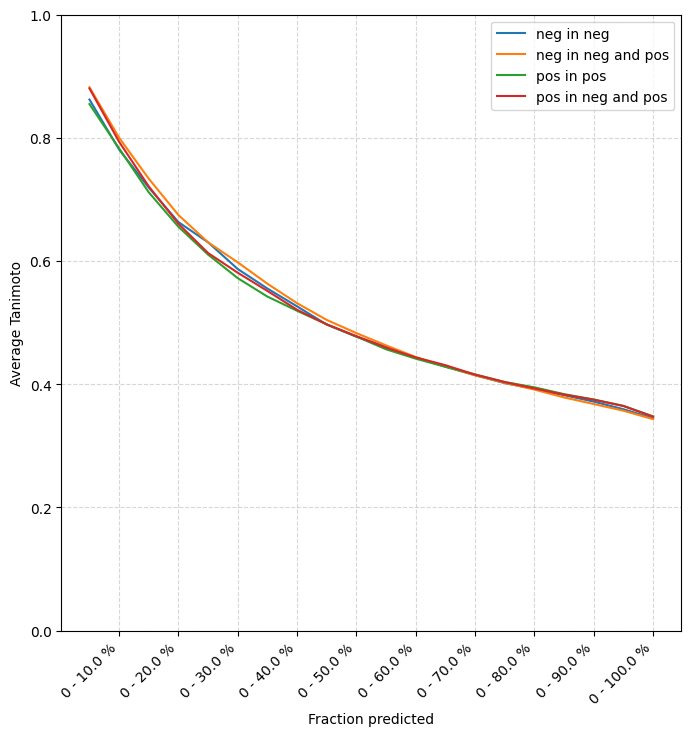

In [396]:
plt.figure(figsize=(8, 8))
plot_comparison_plot({
    "neg in neg": plot_average_per_threshold_inchikeys(threshold_scores_ms2query_2, neg_neg_tanimoto_for_prediction, neg_val_spectra, 20),
    "neg in neg and pos": plot_average_per_threshold_inchikeys(neg_pos_threshold_scores_ms2query_2, neg_pos_tanimoto_for_prediction, neg_val_spectra, 20),
    "pos in pos": plot_average_per_threshold_inchikeys(threshold_score_average_max_top_tanimoto, tanimoto_for_prediction, pos_val_spectra, 20),
    "pos in neg and pos": plot_average_per_threshold_inchikeys(pos_neg_threshold_scores_ms2query_2, pos_neg_tanimoto_for_prediction, pos_val_spectra, 20),
})

# Compare with mod cosine

In [32]:
import pickle
import os
intermediates_folder = "./cross_ionmode_intermediate"

with open(os.path.join(intermediates_folder, "all_fingerprints.pickle"), "rb") as handle:
    all_fingerprints = pickle.load(handle)

In [ ]:
from matchms.similarity.FlashSimilarity import FlashSimilarity
import numpy as np

def analogue_search_in_batches(similarity_metric, train_spectra, val_spectra, batch_size=500):
    """For some reason the argmax seemed to crash our server, so this batch process is a work around"""
    score_matrix = similarity_metric.matrix(train_spectra, val_spectra)
    predicted_inchikeys = []
    predicted_scores = []
    for i in tqdm(range(0, score_matrix.shape[1], batch_size)):
        max_index_chunck = np.argmax(score_matrix[:, i:i+batch_size], axis=0)
        col_idx = np.arange(i, min(i + batch_size, score_matrix.shape[1]))
        predicted_scores.append(score_matrix[max_index_chunck, col_idx])
        for index in max_index_chunck:
            predicted_inchikeys.append(train_spectra[index].get("inchikey")[:14])
    return predicted_inchikeys, np.concatenate(predicted_scores)


In [25]:
mod_cos = FlashSimilarity("cosine", "hybrid", remove_precursor=True)

predicted_inchikeys_mod_cos_neg, predicted_scores_mod_cos_neg = analogue_search_in_batches(mod_cos, neg_train_spectra.spectra, neg_val_spectra.spectra)
tanimoto_for_predictions_mod_cos_neg = get_prediction_tanimoto(predicted_inchikeys_mod_cos_neg, neg_val_spectra, all_fingerprints)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:35<00:00,  1.10s/it]


In [57]:
intermediates_folder = "./neg_neg_intermediate"

with open(os.path.join(intermediates_folder, "mod_cosine_predictions.json"), "w") as f:
    json.dump({"inchikeys": predicted_inchikeys_mod_cos_neg,
              "mod_cosine_score": list(predicted_scores_mod_cos_neg),
              "tanimoto_for_analogues": [float(x) for x in tanimoto_for_predictions_mod_cos_neg]}, f)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 760.27it/s]


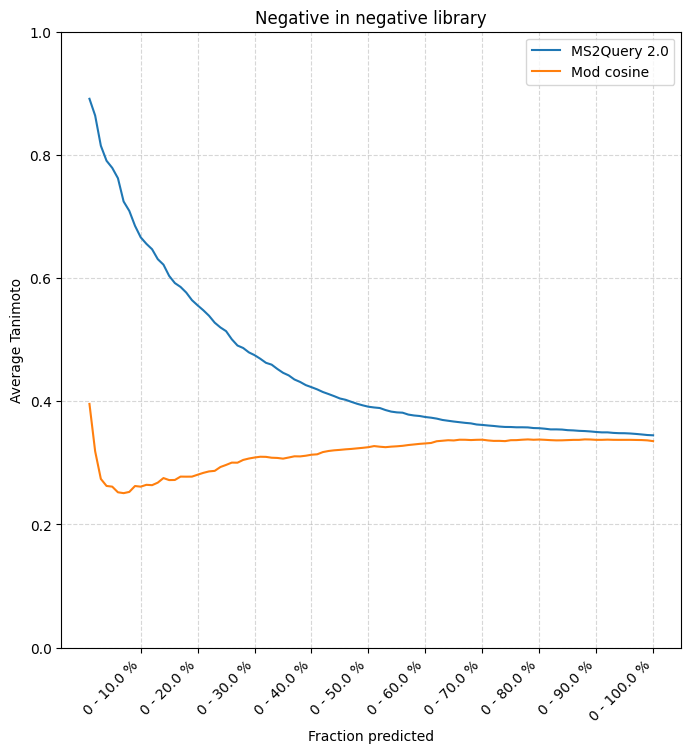

In [67]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 8))
plt.title("Negative in negative library")
plot_comparison_plot({
    "MS2Query 2.0": plot_average_per_threshold(threshold_scores_ms2query_2, neg_neg_tanimoto_for_prediction, neg_val_spectra, 100),
    "Mod cosine": plot_average_per_threshold(predicted_scores_mod_cos_neg, tanimoto_for_predictions_mod_cos_neg, neg_val_spectra, 100),
})

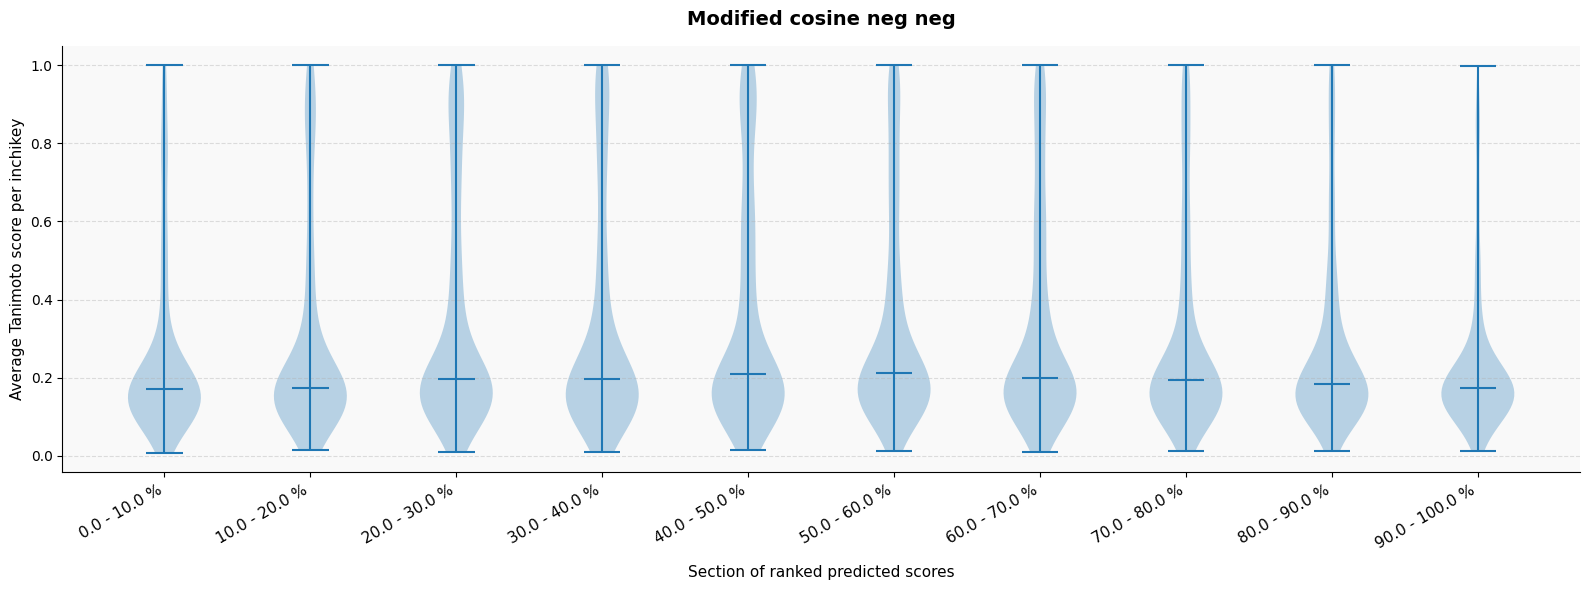

In [85]:
plot_violins(create_values_violin_plot(predicted_scores_mod_cos_neg, neg_val_spectra, tanimoto_for_predictions_mod_cos_neg, 10), title="Modified cosine neg neg")

In [58]:
mod_cos = FlashSimilarity("cosine", "hybrid", remove_precursor=True)

predicted_inchikeys_mod_cos_pos, predicted_scores_mod_cos_pos = analogue_search_in_batches(mod_cos, pos_train_spectra.spectra, pos_val_spectra.spectra)
tanimoto_for_predictions_mod_cos_pos = get_prediction_tanimoto(predicted_inchikeys_mod_cos_pos, pos_val_spectra, all_fingerprints)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:02<00:00, 17829.56it/s]


In [61]:
intermediates_folder = "./pos_pos_intermediate"

with open(os.path.join(intermediates_folder, "mod_cosine_predictions.json"), "w") as f:
    json.dump({"inchikeys": predicted_inchikeys_mod_cos_pos,
              "mod_cosine_score": list(predicted_scores_mod_cos_pos),
              "tanimoto_for_analogues": [float(x) for x in tanimoto_for_predictions_mod_cos_pos]}, f)

In [70]:
pos_pos_ms2query_scores = predict_using_average_max_top_k_tanimoto(8, close_tanimoto_scores)
pos_pos_predicted_inchikeys = [list(query.keys())[0] for query in close_tanimoto_scores]
pos_pos_tanimoto_for_prediction = get_prediction_tanimoto(pos_pos_predicted_inchikeys, pos_val_spectra, all_fingerprints)

36473it [00:05, 6181.06it/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36473/36473 [00:01<00:00, 24448.89it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 338.02it/s]


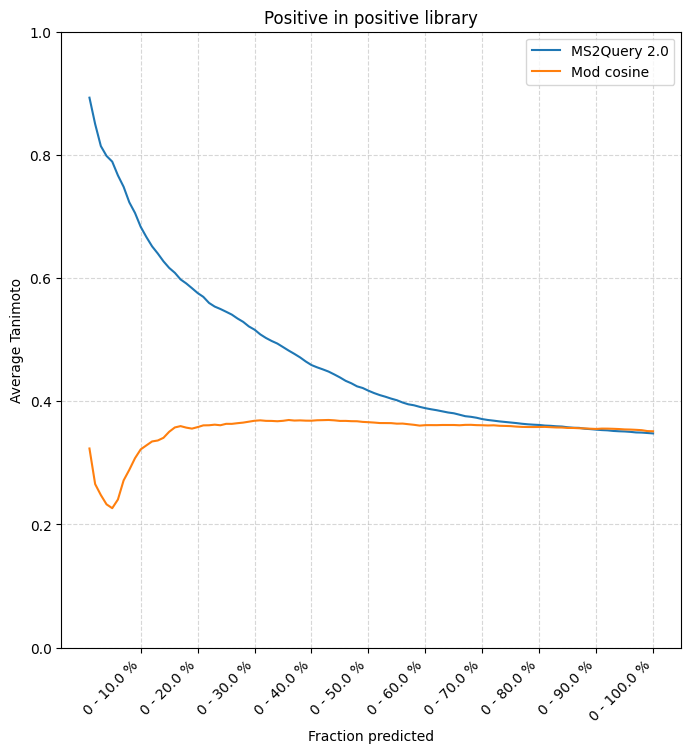

In [71]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 8))
plt.title("Positive in positive library")
plot_comparison_plot({
    "MS2Query 2.0": plot_average_per_threshold(pos_pos_ms2query_scores, pos_pos_tanimoto_for_prediction, pos_val_spectra, 100),
    "Mod cosine": plot_average_per_threshold(predicted_scores_mod_cos_pos, tanimoto_for_predictions_mod_cos_pos, pos_val_spectra, 100),
})

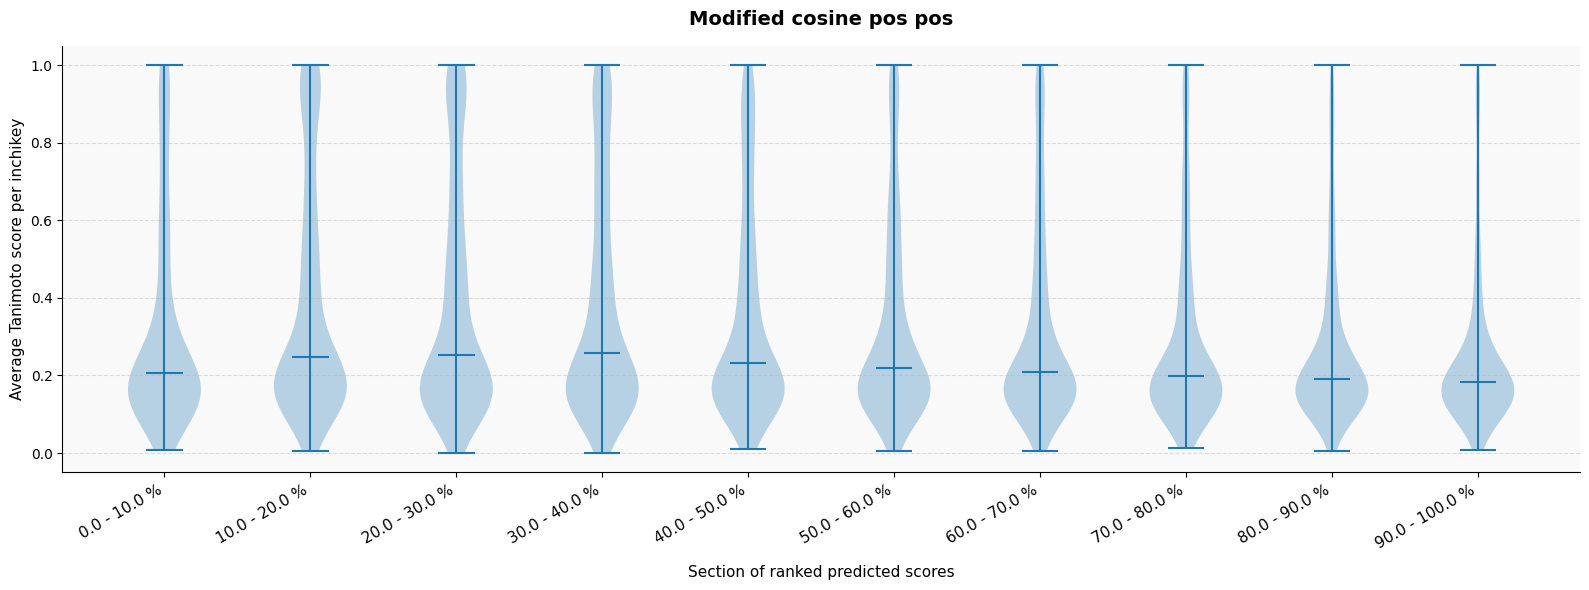

In [74]:
plot_violins(create_values_violin_plot(predicted_scores_mod_cos_pos, pos_val_spectra, tanimoto_for_predictions_mod_cos_pos, 10), title="Modified cosine pos pos")

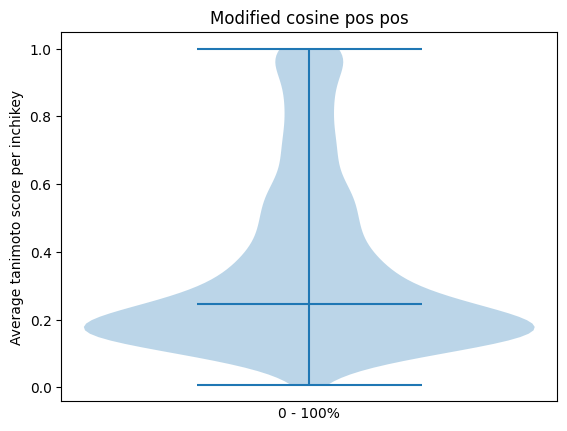

In [75]:
plt.violinplot(create_values_violin_plot(predicted_scores_mod_cos_pos, pos_val_spectra, tanimoto_for_predictions_mod_cos_pos, 1), showmedians=True)
plt.title("Modified cosine pos pos")
plt.ylabel("Average tanimoto score per inchikey")
plt.xticks([])
plt.xlabel("0 - 100%")
plt.show()


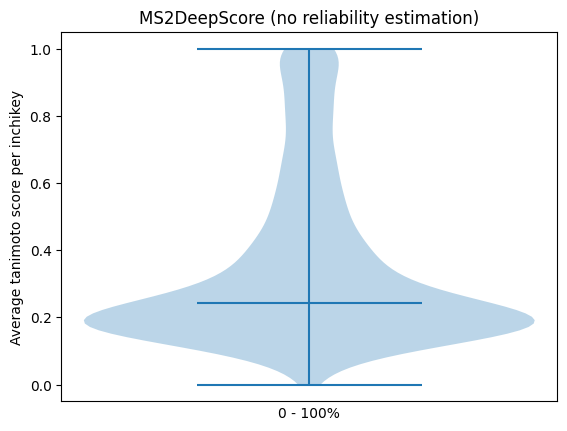

In [77]:
plt.violinplot(create_values_violin_plot(pos_pos_ms2query_scores, pos_val_spectra, pos_pos_tanimoto_for_prediction, 1), showmedians=True)
plt.title("MS2DeepScore (no reliability estimation)")
plt.ylabel("Average tanimoto score per inchikey")
plt.xticks([])
plt.xlabel("0 - 100%")
plt.show()